# Receptor (14-3-3) and stabilizer (FSC) without ligand (H$^{+}$ ATPase)

## Build topology files with `tleap`

### Receptor + FSC

1. Create copy of `amber_o98.B99990002_FSC.pdb`
2. Delete ligand protein atoms manually (residues 243-294)
3. Rename to `amber_2o98.B99990002_receptor_FSC.pdb`

`tleap`
```tleap
> source leaprc.protein.ff19SB
----- Source: /home/t38guest/amber22/dat/leap/cmd/leaprc.protein.ff19SB
----- Source of /home/t38guest/amber22/dat/leap/cmd/leaprc.protein.ff19SB done
Log file: ./leap.log
Loading parameters: /home/t38guest/amber22/dat/leap/parm/parm19.dat
Reading title:
PARM99 + frcmod.ff99SB + frcmod.parmbsc0 + OL3 for RNA + ff19SB
Loading parameters: /home/t38guest/amber22/dat/leap/parm/frcmod.ff19SB
Reading force field modification type file (frcmod)
Reading title:
ff19SB AA-specific backbone CMAPs for protein 07/25/2019
Loading library: /home/t38guest/amber22/dat/leap/lib/amino19.lib
Loading library: /home/t38guest/amber22/dat/leap/lib/aminoct12.lib
Loading library: /home/t38guest/amber22/dat/leap/lib/aminont12.lib
```
```tleap
> source leaprc.water.opc
----- Source: /home/t38guest/amber22/dat/leap/cmd/leaprc.water.opc
----- Source of /home/t38guest/amber22/dat/leap/cmd/leaprc.water.opc done
Loading library: /home/t38guest/amber22/dat/leap/lib/atomic_ions.lib
Loading library: /home/t38guest/amber22/dat/leap/lib/solvents.lib
Loading parameters: /home/t38guest/amber22/dat/leap/parm/frcmod.opc
Reading force field modification type file (frcmod)
Reading title:
Parameters for OPC water (JPCL, 2014, 5 (21), pp 3863-3871)
Loading parameters: /home/t38guest/amber22/dat/leap/parm/frcmod.ionslm_126_opc
Reading force field modification type file (frcmod)
Reading title:
Li/Merz ion parameters of atomic ions for the OPC water model (12-6 set)
```
```tleap
> source leaprc.gaff
----- Source: /home/t38guest/amber22/dat/leap/cmd/leaprc.gaff
----- Source of /home/t38guest/amber22/dat/leap/cmd/leaprc.gaff done
Log file: ./leap.log
Loading parameters: /home/t38guest/amber22/dat/leap/parm/gaff.dat
Reading title:
AMBER General Force Field for organic molecules (Version 1.81, May 2017)
```
```tleap
> loadamberparams antechamber_o98_FSC1001_h.frcmod
Loading parameters: ./antechamber_o98_FSC1001_h.frcmod
Reading force field modification type file (frcmod)
Reading title:
Remark line goes here
```
```tleap
> loadoff antechamber_o98_FSC1001_h.lib
Loading library: ./antechamber_o98_FSC1001_h.lib
```
```tleap
> complex = loadpdb amber_2o98.B99990002_receptor_FSC.pdb
Loading PDB file: /home/wjoon21/project/chen2023_possible_allosteric/B2/trial9_param_FSC_terminal_finished/amber_o98.B99990002_receptor_FSC.pdb
  total atoms in file: 1971
  Leap added 1964 missing atoms according to residue templates:
       1964 H / lone pairs
> saveamberparm complex amber_2o98_receptor_FSC_gas.parm7 amber_2o98_receptor_FSC_gas.rst7
Checking Unit.

Warning: The unperturbed charge of the unit (-10.998995) is not zero.

Note: Ignoring the warning from Unit Checking.

Building topology.
Building atom parameters.
Building bond parameters.
Building angle parameters.
Building proper torsion parameters.
Building improper torsion parameters.
 total 754 improper torsions applied
Building H-Bond parameters.
Incorporating Non-Bonded adjustments.
Not Marking per-residue atom chain types.
Marking per-residue atom chain types.
  (Residues lacking connect0/connect1 - 
   these don't have chain types marked:

        res     total affected

        CGLN    1
        FSC     1
        NMET    1
  )
 (no restraints)
```
```tleap
> savepdb complex amber_2o98_receptor_FSC_gas.pdb
Writing pdb file: amber_2o98_receptor_FSC_gas.pdb

Warning:  Converting N-terminal residue name to PDB format: NMET -> MET

Warning:  Converting C-terminal residue name to PDB format: CGLN -> GLN
> addIons complex Na+ 11
Adding 11 counter ions to "complex" using 1A grid
Grid extends from solute vdw + 3.36  to  9.34
Resolution:      1.00 Angstrom.
 (no solvent present)
Calculating grid charges
Placed Na+ in complex at (5.90, 76.10, 144.47).
Placed Na+ in complex at (-19.10, 63.10, 118.47).
Placed Na+ in complex at (14.90, 82.10, 137.47).
Placed Na+ in complex at (20.90, 81.10, 97.47).
Placed Na+ in complex at (-9.10, 52.10, 100.47).
Placed Na+ in complex at (-4.10, 75.10, 145.47).
Placed Na+ in complex at (28.90, 82.10, 129.47).
Placed Na+ in complex at (-1.10, 92.10, 143.47).
Placed Na+ in complex at (16.90, 53.10, 121.47).
Placed Na+ in complex at (1.90, 91.10, 102.47).
Placed Na+ in complex at (-2.10, 58.10, 88.47).

Done adding ions.
```
```tleap
> solvateBox complex OPCBOX 12.5
  Solute vdw bounding box:              60.609 64.951 60.613
  Total bounding box for atom centers:  85.609 89.951 85.613
  Solvent unit box:                     18.865 18.478 19.006
  Total vdw box size:                   88.461 93.209 88.443 angstroms.
  Volume: 729242.743 A^3 
  Total mass 367253.800 amu,  Density 0.836 g/cc
  Added 18813 residues.
```

In [1]:
volumeBoxAngstrom = 729242.743
volumeBoxLiter = volumeBoxAngstrom * 1/(10**10)**3 * (10**2)**3/1 * 1/1 * 1/10**3
numberClLiter = 150/1 * 1/10**3 * (6.022*10**23)/1
numberClBox = volumeBoxLiter * numberClLiter
numberClBox

65.87249697519

```tleap
> addIonsRand complex Na+ 66 Cl- 66
Adding 132 counter ions to "complex". 18681 solvent molecules will remain.
0: Placed Na+ in complex at (-25.74, -40.46, -27.96).
Placed Cl- in complex at (-33.01, -28.69, 18.66).
0: Placed Na+ in complex at (16.72, 40.82, 3.04).
Placed Cl- in complex at (-39.74, 37.91, 22.36).
0: Placed Na+ in complex at (5.80, -32.12, 11.34).
Placed Cl- in complex at (-17.16, 16.88, 20.04).
0: Placed Na+ in complex at (41.44, -19.78, -32.47).
Placed Cl- in complex at (37.41, 13.24, -1.61).
0: Placed Na+ in complex at (10.20, 25.74, -40.15).
Placed Cl- in complex at (-27.53, -11.21, -40.15).
0: Placed Na+ in complex at (-15.17, -14.05, -34.58).
Placed Cl- in complex at (26.76, 34.20, 10.98).
0: Placed Na+ in complex at (1.80, 30.07, -20.37).
Placed Cl- in complex at (39.99, 19.34, -14.27).
0: Placed Na+ in complex at (35.58, -33.09, 22.04).
Placed Cl- in complex at (28.88, -15.71, 10.81).
0: Placed Na+ in complex at (38.04, -13.30, 10.62).
Placed Cl- in complex at (-31.45, 33.63, -2.01).
0: Placed Na+ in complex at (-8.85, -36.80, -24.41).
Placed Cl- in complex at (-19.64, -33.63, -4.21).
0: Placed Na+ in complex at (-20.49, 0.30, 31.90).
Placed Cl- in complex at (11.99, 8.48, 25.81).
0: Placed Na+ in complex at (-1.46, 10.61, -39.55).
Placed Cl- in complex at (-40.78, -22.30, -20.13).
0: Placed Na+ in complex at (37.60, 19.79, -19.18).
Placed Cl- in complex at (-17.06, 11.59, -20.37).
0: Placed Na+ in complex at (-2.01, 19.43, 3.35).
Placed Cl- in complex at (-20.14, 34.14, -9.41).
0: Placed Na+ in complex at (15.49, 26.52, 9.72).
Placed Cl- in complex at (-15.59, -34.92, -21.45).
0: Placed Na+ in complex at (-3.10, -10.21, 26.10).
Placed Cl- in complex at (-5.21, 34.34, 31.10).
0: Placed Na+ in complex at (39.63, -8.52, -22.64).
Placed Cl- in complex at (9.65, -30.36, -31.15).
0: Placed Na+ in complex at (-17.23, 18.37, -29.29).
Placed Cl- in complex at (-15.59, -16.45, -40.45).
0: Placed Na+ in complex at (28.52, 43.55, -12.14).
Placed Cl- in complex at (-36.54, -21.02, -11.88).
0: Placed Na+ in complex at (-24.56, 34.94, -11.05).
Placed Cl- in complex at (41.00, 2.03, 16.57).
0: Placed Na+ in complex at (26.43, 9.83, -10.88).
Placed Cl- in complex at (-29.45, -25.13, -35.59).
0: Placed Na+ in complex at (7.90, -28.21, 16.27).
Placed Cl- in complex at (22.08, -23.42, -28.25).
0: Placed Na+ in complex at (-5.70, 34.94, 26.96).
Placed Cl- in complex at (-15.69, 23.46, -12.15).
0: Placed Na+ in complex at (7.85, -12.64, -25.00).
Placed Cl- in complex at (0.53, 21.26, 25.05).
0: Placed Na+ in complex at (-30.67, -17.61, 14.21).
Placed Cl- in complex at (34.59, -25.64, 3.27).
0: Placed Na+ in complex at (-12.06, 37.49, 21.39).
Placed Cl- in complex at (13.33, -35.36, -27.34).
0: Placed Na+ in complex at (-31.20, 19.54, -32.88).
Placed Cl- in complex at (34.81, -4.11, -13.74).
0: Placed Na+ in complex at (-26.60, 13.82, 42.22).
Placed Cl- in complex at (-3.08, -11.21, -39.43).
0: Placed Na+ in complex at (-9.68, -1.04, -9.47).
Placed Cl- in complex at (-1.27, -21.30, 28.60).
0: Placed Na+ in complex at (10.09, 11.86, 19.27).
Placed Cl- in complex at (-13.47, -43.33, 39.45).
0: Placed Na+ in complex at (14.43, -7.01, -41.78).
Placed Cl- in complex at (-6.82, 37.26, 8.72).
0: Placed Na+ in complex at (-22.69, 4.50, -39.92).
Placed Cl- in complex at (9.68, -31.63, -9.44).
0: Placed Na+ in complex at (32.55, 29.71, -31.39).
Placed Cl- in complex at (29.25, 5.27, 2.74).
0: Placed Na+ in complex at (-2.53, -4.60, -35.72).
Placed Cl- in complex at (-21.36, 30.23, -31.01).
0: Placed Na+ in complex at (18.35, 7.73, 21.56).
Placed Cl- in complex at (-22.94, 8.49, 23.33).
0: Placed Na+ in complex at (41.65, 26.28, 22.16).
Placed Cl- in complex at (10.53, 0.57, 23.44).
0: Placed Na+ in complex at (-24.58, -9.42, -3.26).
Placed Cl- in complex at (-11.01, -31.12, -25.00).
0: Placed Na+ in complex at (-17.44, 21.83, 21.59).
Placed Cl- in complex at (4.17, 20.13, 21.49).
0: Placed Na+ in complex at (-34.26, 13.11, -4.93).
Placed Cl- in complex at (19.66, 19.79, -2.87).
0: Placed Na+ in complex at (-14.08, 20.99, -31.04).
Placed Cl- in complex at (33.90, -32.45, 17.10).
0: Placed Na+ in complex at (2.81, 29.88, 26.79).
Placed Cl- in complex at (-1.27, 15.66, 9.59).
0: Placed Na+ in complex at (-14.14, 26.74, -38.36).
Placed Cl- in complex at (-24.79, 11.40, 22.92).
0: Placed Na+ in complex at (18.50, -29.27, -2.24).
Placed Cl- in complex at (31.69, 18.40, 12.98).
0: Placed Na+ in complex at (28.88, 18.63, 13.61).
Placed Cl- in complex at (32.03, 34.94, 26.96).
0: Placed Na+ in complex at (26.72, 24.32, 13.01).
Placed Cl- in complex at (10.95, 0.99, -19.20).
0: Placed Na+ in complex at (-30.52, -15.34, 16.05).
Placed Cl- in complex at (-9.68, 17.44, -28.48).
0: Placed Na+ in complex at (-12.59, -40.28, 36.00).
Placed Cl- in complex at (-39.27, 34.87, -31.17).
0: Placed Na+ in complex at (-33.91, 30.03, 11.67).
Placed Cl- in complex at (6.61, -44.03, -3.17).
0: Placed Na+ in complex at (-38.05, -23.72, -1.61).
Placed Cl- in complex at (39.37, -37.07, 8.73).
0: Placed Na+ in complex at (5.49, 27.46, 12.27).
Placed Cl- in complex at (18.92, -22.38, 38.80).
0: Placed Na+ in complex at (-21.79, -4.11, 5.27).
Placed Cl- in complex at (6.48, 35.37, 25.81).
0: Placed Na+ in complex at (8.06, 19.08, -19.19).
Placed Cl- in complex at (-27.29, -15.94, -3.51).
0: Placed Na+ in complex at (-36.77, 30.54, 39.65).
Placed Cl- in complex at (-20.32, -26.35, 17.46).
0: Placed Na+ in complex at (-38.50, 3.32, -23.22).
Placed Cl- in complex at (20.29, 40.31, 21.59).
0: Placed Na+ in complex at (38.81, -7.61, 31.88).
Placed Cl- in complex at (34.57, -26.86, -7.27).
0: Placed Na+ in complex at (39.36, 26.63, -33.65).
Placed Cl- in complex at (41.00, -15.42, -37.72).
0: Placed Na+ in complex at (1.90, 28.44, -3.64).
Placed Cl- in complex at (38.46, -3.33, -41.34).
0: Placed Na+ in complex at (16.03, 44.83, -5.26).
Placed Cl- in complex at (-30.93, 19.01, 40.39).
0: Placed Na+ in complex at (-16.14, -30.55, 9.41).
Placed Cl- in complex at (34.65, 7.27, -39.43).
0: Placed Na+ in complex at (-24.37, -21.59, 23.94).
Placed Cl- in complex at (-11.94, 16.60, -15.00).
0: Placed Na+ in complex at (-30.52, 21.62, 35.06).
Placed Cl- in complex at (3.61, 41.59, -25.32).
0: Placed Na+ in complex at (22.82, -4.67, 18.01).
Placed Cl- in complex at (-1.11, 10.22, 39.27).
0: Placed Na+ in complex at (11.28, -32.32, -13.62).
Placed Cl- in complex at (-18.55, 23.66, 10.62).
0: Placed Na+ in complex at (-31.45, 15.15, 17.00).
Placed Cl- in complex at (-25.75, -16.42, 25.43).
0: Placed Na+ in complex at (32.87, 30.74, -8.09).
Placed Cl- in complex at (-13.96, -13.88, -3.20).
0: Placed Na+ in complex at (-12.25, 29.88, -3.17).
Placed Cl- in complex at (22.57, -38.26, 5.54).
```
```tleap
> saveamberparm complex amber_2o98_receptor_FSC_cubic_ion.parm7 amber_2o98_receptor_FSC_cubic_ion.rst7
Checking Unit.

Note: Ignoring the warnings from Unit Checking.

Building topology.
Building atom parameters.
Building bond parameters.
Building angle parameters.
Building proper torsion parameters.
Building improper torsion parameters.
 total 754 improper torsions applied
Building H-Bond parameters.
Incorporating Non-Bonded adjustments.
Not Marking per-residue atom chain types.
Marking per-residue atom chain types.
  (Residues lacking connect0/connect1 - 
   these don't have chain types marked:

        res     total affected

        CGLN    1
        FSC     1
        NMET    1
  )
 (no restraints)
```
accidentally terminated `tleap` with Ctrl+C in terminal...\
but the required `.parm7` and `.rst7` files have already been generated

### Receptor only

```tleap
> source leaprc.protein.ff19SB
----- Source: /home/t38guest/amber22/dat/leap/cmd/leaprc.protein.ff19SB
----- Source of /home/t38guest/amber22/dat/leap/cmd/leaprc.protein.ff19SB done
Log file: ./leap.log
Loading parameters: /home/t38guest/amber22/dat/leap/parm/parm19.dat
Reading title:
PARM99 + frcmod.ff99SB + frcmod.parmbsc0 + OL3 for RNA + ff19SB
Loading parameters: /home/t38guest/amber22/dat/leap/parm/frcmod.ff19SB
Reading force field modification type file (frcmod)
Reading title:
ff19SB AA-specific backbone CMAPs for protein 07/25/2019
Loading library: /home/t38guest/amber22/dat/leap/lib/amino19.lib
Loading library: /home/t38guest/amber22/dat/leap/lib/aminoct12.lib
Loading library: /home/t38guest/amber22/dat/leap/lib/aminont12.lib

> source leaprc.water.opc
----- Source: /home/t38guest/amber22/dat/leap/cmd/leaprc.water.opc
----- Source of /home/t38guest/amber22/dat/leap/cmd/leaprc.water.opc done
Loading library: /home/t38guest/amber22/dat/leap/lib/atomic_ions.lib
Loading library: /home/t38guest/amber22/dat/leap/lib/solvents.lib
Loading parameters: /home/t38guest/amber22/dat/leap/parm/frcmod.opc
Reading force field modification type file (frcmod)
Reading title:
Parameters for OPC water (JPCL, 2014, 5 (21), pp 3863-3871)
Loading parameters: /home/t38guest/amber22/dat/leap/parm/frcmod.ionslm_126_opc
Reading force field modification type file (frcmod)
Reading title:
Li/Merz ion parameters of atomic ions for the OPC water model (12-6 set)

> receptor=loadpdb amber_2o98.B99990002_receptor.pdb
Loading PDB file: ./amber_2o98.B99990002_receptor.pdb
  total atoms in file: 1923
  Leap added 1908 missing atoms according to residue templates:
       1908 H / lone pairs

> saveamberparm receptor amber_2o98_receptor_gas.parm7 amber_2o98_receptor_gas.rst7 
Checking Unit.

Warning: The unperturbed charge of the unit (-11.000000) is not zero.

Note: Ignoring the warning from Unit Checking.

Building topology.
Building atom parameters.
Building bond parameters.
Building angle parameters.
Building proper torsion parameters.
Building improper torsion parameters.
 total 746 improper torsions applied
Building H-Bond parameters.
Incorporating Non-Bonded adjustments.
Not Marking per-residue atom chain types.
Marking per-residue atom chain types.
  (Residues lacking connect0/connect1 - 
   these don't have chain types marked:

        res     total affected

        CGLN    1
        NMET    1
  )
 (no restraints)

> addIons receptor Na+ 11
Adding 11 counter ions to "receptor" using 1A grid
Grid extends from solute vdw + 3.36  to  9.34
Resolution:      1.00 Angstrom.
 (no solvent present)
Calculating grid charges
Placed Na+ in receptor at (5.90, 76.10, 144.47).
Placed Na+ in receptor at (-19.10, 63.10, 118.47).
Placed Na+ in receptor at (14.90, 82.10, 137.47).
Placed Na+ in receptor at (20.90, 81.10, 97.47).
Placed Na+ in receptor at (-9.10, 52.10, 100.47).
Placed Na+ in receptor at (-4.10, 75.10, 145.47).
Placed Na+ in receptor at (28.90, 82.10, 129.47).
Placed Na+ in receptor at (-1.10, 92.10, 143.47).
Placed Na+ in receptor at (16.90, 53.10, 121.47).
Placed Na+ in receptor at (1.90, 91.10, 102.47).
Placed Na+ in receptor at (-2.10, 58.10, 88.47).

Done adding ions.

> solvateBox receptor OPCBOX 12.5
  Solute vdw bounding box:              60.609 64.951 60.613
  Total bounding box for atom centers:  85.609 89.951 85.613
  Solvent unit box:                     18.865 18.478 19.006
  Total vdw box size:                   88.461 93.209 88.443 angstroms.
  Volume: 729242.743 A^3 
  Total mass 367077.440 amu,  Density 0.836 g/cc
  Added 18841 residues.
```

In [3]:
volumeBoxAngstrom = 729242.743
volumeBoxLiter = volumeBoxAngstrom * 1/(10**10)**3 * (10**2)**3/1 * 1/1 * 1/10**3
numberClLiter = 150/1 * 1/10**3 * (6.022*10**23)/1
numberClBox = volumeBoxLiter * numberClLiter
numberClBox

65.87249697519

```tleap
> addIonsRand receptor Na+ 66 Cl- 66
Na+ has a charge of 0.
Adding the ions anyway.
Adding 132 counter ions to "receptor". 18709 solvent molecules will remain.
0: Placed Na+ in receptor at (8.06, -17.87, 18.83).
Placed Cl- in receptor at (40.45, -12.07, -28.60).
0: Placed Na+ in receptor at (33.25, -33.64, 20.27).
Placed Cl- in receptor at (40.21, -2.42, -39.63).
0: Placed Na+ in receptor at (26.05, 32.07, -13.58).
Placed Cl- in receptor at (-10.58, -25.13, -16.59).
0: Placed Na+ in receptor at (-29.83, 34.20, -8.02).
Placed Cl- in receptor at (4.38, -19.01, -40.30).
0: Placed Na+ in receptor at (21.99, -26.71, -18.11).
Placed Cl- in receptor at (-38.27, 7.39, 31.15).
0: Placed Na+ in receptor at (13.82, 36.17, -19.32).
Placed Cl- in receptor at (35.80, 5.99, -13.93).
0: Placed Na+ in receptor at (23.08, -1.90, -10.57).
Placed Cl- in receptor at (3.17, 4.98, -31.15).
0: Placed Na+ in receptor at (-34.52, -4.94, 28.77).
Placed Cl- in receptor at (18.27, 0.69, 29.07).
0: Placed Na+ in receptor at (0.31, 23.66, 29.62).
Placed Cl- in receptor at (22.14, 2.03, -40.45).
0: Placed Na+ in receptor at (-6.89, -16.42, -31.59).
Placed Cl- in receptor at (-34.04, 41.39, -34.58).
0: Placed Na+ in receptor at (35.72, 19.43, 22.36).
Placed Cl- in receptor at (2.72, -12.07, 28.42).
0: Placed Na+ in receptor at (25.35, -38.54, 25.81).
Placed Cl- in receptor at (8.72, 39.59, -13.27).
0: Placed Na+ in receptor at (-2.15, 40.82, 3.04).
Placed Cl- in receptor at (-15.16, -1.30, 24.55).
0: Placed Na+ in receptor at (-2.01, -36.00, -34.66).
Placed Cl- in receptor at (-15.55, 7.40, 30.87).
0: Placed Na+ in receptor at (-11.01, -31.12, 32.02).
Placed Cl- in receptor at (-20.43, -5.45, -25.55).
0: Placed Na+ in receptor at (-40.62, -13.27, -26.84).
Placed Cl- in receptor at (-17.79, 13.93, -6.02).
0: Placed Na+ in receptor at (-24.31, -35.14, -40.07).
Placed Cl- in receptor at (10.29, 16.03, -38.05).
0: Placed Na+ in receptor at (10.32, -7.86, -11.71).
Placed Cl- in receptor at (40.77, 34.35, 41.11).
0: Placed Na+ in receptor at (-0.54, 25.87, -6.86).
Placed Cl- in receptor at (-39.36, -36.65, 31.90).
0: Placed Na+ in receptor at (-26.60, 32.30, 23.21).
Placed Cl- in receptor at (6.80, -36.42, 21.39).
0: Placed Na+ in receptor at (-20.79, 5.99, 5.07).
Placed Cl- in receptor at (-36.28, 5.53, -1.50).
0: Placed Na+ in receptor at (-39.74, 37.91, 3.35).
Placed Cl- in receptor at (-9.36, 30.44, 10.66).
0: Placed Na+ in receptor at (7.19, -41.85, 5.42).
Placed Cl- in receptor at (-14.48, -19.01, -40.30).
0: Placed Na+ in receptor at (-15.69, 41.94, -12.15).
Placed Cl- in receptor at (21.59, 43.36, 28.42).
0: Placed Na+ in receptor at (8.72, 39.59, 24.75).
Placed Cl- in receptor at (13.82, -37.74, 18.70).
0: Placed Na+ in receptor at (28.57, -5.35, 6.32).
Placed Cl- in receptor at (7.90, -9.73, -40.75).
0: Placed Na+ in receptor at (-3.05, -40.78, 17.88).
Placed Cl- in receptor at (-30.67, -17.61, 14.21).
0: Placed Na+ in receptor at (9.19, 6.24, 19.35).
Placed Cl- in receptor at (-10.26, -4.97, -40.96).
0: Placed Na+ in receptor at (10.64, -42.71, -23.77).
Placed Cl- in receptor at (-13.16, -19.57, -38.08).
0: Placed Na+ in receptor at (34.81, -41.06, 24.28).
Placed Cl- in receptor at (-2.89, 5.21, -26.84).
0: Placed Na+ in receptor at (-6.88, 8.48, 6.80).
Placed Cl- in receptor at (5.40, -24.85, -17.57).
0: Placed Na+ in receptor at (-40.56, -31.85, 33.35).
Placed Cl- in receptor at (-21.05, -31.05, 1.15).
0: Placed Na+ in receptor at (-30.24, 6.98, 4.96).
Placed Cl- in receptor at (-21.12, -39.55, -6.27).
0: Placed Na+ in receptor at (-39.91, -12.57, -17.86).
Placed Cl- in receptor at (-18.40, 44.52, 7.03).
0: Placed Na+ in receptor at (22.82, 32.29, 37.01).
Placed Cl- in receptor at (37.14, 37.64, 10.07).
0: Placed Na+ in receptor at (5.28, 33.62, -36.46).
Placed Cl- in receptor at (-1.54, 34.87, 6.85).
0: Placed Na+ in receptor at (41.20, -5.37, -23.94).
Placed Cl- in receptor at (-2.84, 7.87, -5.26).
0: Placed Na+ in receptor at (37.21, -10.75, 21.56).
Placed Cl- in receptor at (29.39, 0.57, 23.44).
0: Placed Na+ in receptor at (38.46, -3.33, -22.33).
Placed Cl- in receptor at (-39.36, -7.43, -4.48).
0: Placed Na+ in receptor at (-38.84, -8.26, 20.26).
Placed Cl- in receptor at (31.81, 29.87, -15.09).
0: Placed Na+ in receptor at (28.43, 44.71, -6.80).
Placed Cl- in receptor at (24.66, -13.64, -26.68).
0: Placed Na+ in receptor at (10.32, 29.09, -30.72).
Placed Cl- in receptor at (-40.57, -29.09, -24.27).
0: Placed Na+ in receptor at (12.95, -15.25, -23.44).
Placed Cl- in receptor at (26.59, 0.79, -10.91).
0: Placed Na+ in receptor at (-21.94, 25.75, -39.43).
Placed Cl- in receptor at (28.54, 5.33, -9.44).
0: Placed Na+ in receptor at (-39.91, -31.05, -36.87).
Placed Cl- in receptor at (13.30, 4.28, -26.24).
0: Placed Na+ in receptor at (30.85, -40.46, 29.06).
Placed Cl- in receptor at (38.69, -43.37, -36.37).
0: Placed Na+ in receptor at (-15.05, 11.55, -26.34).
Placed Cl- in receptor at (-40.83, -10.21, 7.09).
0: Placed Na+ in receptor at (28.69, 16.34, 4.21).
Placed Cl- in receptor at (-42.17, -25.49, 15.24).
0: Placed Na+ in receptor at (-5.72, 27.54, -22.27).
Placed Cl- in receptor at (-5.51, -30.31, -29.56).
0: Placed Na+ in receptor at (34.68, -22.30, -20.13).
Placed Cl- in receptor at (-19.23, 7.68, -40.26).
0: Placed Na+ in receptor at (-4.86, -24.70, 10.91).
Placed Cl- in receptor at (35.48, -2.59, -6.27).
0: Placed Na+ in receptor at (19.33, -29.40, -30.99).
Placed Cl- in receptor at (-25.15, 19.48, 40.15).
0: Placed Na+ in receptor at (1.08, -23.03, 31.99).
Placed Cl- in receptor at (-3.16, 10.09, 30.74).
0: Placed Na+ in receptor at (-22.57, -1.05, 29.03).
Placed Cl- in receptor at (25.34, -9.01, -34.89).
0: Placed Na+ in receptor at (16.37, -43.68, -31.01).
Placed Cl- in receptor at (37.21, 26.21, -16.46).
0: Placed Na+ in receptor at (5.49, -9.50, 31.27).
Placed Cl- in receptor at (26.28, -34.87, -26.40).
0: Placed Na+ in receptor at (-23.59, 5.51, 25.02).
Placed Cl- in receptor at (-17.79, -4.55, -6.02).
0: Placed Na+ in receptor at (16.72, 40.82, -34.98).
Placed Cl- in receptor at (-23.59, 23.98, -32.00).
0: Placed Na+ in receptor at (-10.80, -36.35, 18.83).
Placed Cl- in receptor at (-8.42, 2.54, -22.52).
0: Placed Na+ in receptor at (1.75, -32.01, 33.77).
Placed Cl- in receptor at (-32.01, 13.01, 27.37).
0: Placed Na+ in receptor at (30.61, -31.02, 14.80).
Placed Cl- in receptor at (-0.77, 40.28, -23.22).
0: Placed Na+ in receptor at (28.88, 18.63, 13.61).
Placed Cl- in receptor at (12.58, -17.48, 21.15).
0: Placed Na+ in receptor at (-23.59, 5.51, -12.99).
Placed Cl- in receptor at (32.55, 29.71, -31.39).
0: Placed Na+ in receptor at (0.37, 0.29, -16.48).
Placed Cl- in receptor at (-5.55, -7.63, 38.46).
0: Placed Na+ in receptor at (1.71, -20.08, -36.98).
Placed Cl- in receptor at (-9.67, 34.99, -31.05).
0: Placed Na+ in receptor at (31.05, -28.41, -38.83).
Placed Cl- in receptor at (34.84, -13.27, 30.18).

> saveamberparm receptor amber_2o98_receptor_cubic_ion.parm7 amber_2o98_receptor_cubic_ion.rst7
Checking Unit.

Note: Ignoring the warnings from Unit Checking.

Building topology.
Building atom parameters.
Building bond parameters.
Building angle parameters.
Building proper torsion parameters.
Building improper torsion parameters.
 total 746 improper torsions applied
Building H-Bond parameters.
Incorporating Non-Bonded adjustments.
Not Marking per-residue atom chain types.
Marking per-residue atom chain types.
  (Residues lacking connect0/connect1 - 
   these don't have chain types marked:

        res     total affected

        CGLN    1
        NMET    1
  )
 (no restraints)
```

## Minimize, heat & equilibrate with AMBER22 (local machine)
NVIDIA GeForce GTX 1070

## Dry with `cpptraj`

### Receptor + FSC

```sh
cpptraj -p amber_2o98_receptor_FSC_cubic_ion.parm7 -y 9md.rst7 
```
```cpptraj
CPPTRAJ: Trajectory Analysis. V6.4.4 (AmberTools)
    ___  ___  ___  ___
     | \/ | \/ | \/ | 
    _|_/\_|_/\_|_/\_|_

| Date/time: 07/16/24 13:25:09
| Available memory: 2.777 GB

        Reading 'amber_2o98_receptor_FSC_cubic_ion.parm7' as Amber Topology
        Radius Set: modified Bondi radii (mbondi)
        Reading '9md.rst7' as Amber NC Restart
        Loading previous history from log 'cpptraj.log'
> strip :WAT,Na+,Cl- parmout amber_2o98_receptor_FSC_dry.parm7
  [strip :WAT,Na+,Cl- parmout amber_2o98_receptor_FSC_dry.parm7]
    STRIP: Stripping atoms in mask [:WAT,Na+,Cl-]
        Writing 'stripped' topology file with name 'amber_2o98_receptor_FSC_dry.parm7'
> trajout amber_2o98_receptor_FSC_equil_dry.rst7
  [trajout amber_2o98_receptor_FSC_equil_dry.rst7]
        Writing 'amber_2o98_receptor_FSC_equil_dry.rst7' as Amber Restart
> go
  [go]
---------- RUN BEGIN -------------------------------------------------

PARAMETER FILES (1 total):
 0: amber_2o98_receptor_FSC_cubic_ion.parm7, 78802 atoms, 19067 res, box: Orthorhombic, 18826 mol, 18681 solvent

INPUT TRAJECTORIES (1 total):
 0: '9md.rst7' is a NetCDF AMBER restart file with coordinates, velocities, time, box, Parm amber_2o98_receptor_FSC_cubic_ion.parm7 (Orthorhombic box) (reading 1 of 1)
  Coordinate processing will occur on 1 frames.

OUTPUT TRAJECTORIES (1 total):
  'amber_2o98_receptor_FSC_equil_dry.rst7' (1 frames) is an AMBER restart file

BEGIN TRAJECTORY PROCESSING:
.....................................................
ACTION SETUP FOR PARM 'amber_2o98_receptor_FSC_cubic_ion.parm7' (1 actions):
  0: [strip :WAT,Na+,Cl- parmout amber_2o98_receptor_FSC_dry.parm7]
        Stripping 74867 atoms.
        Stripped topology: 3935 atoms, 243 res, box: Orthorhombic, 2 mol
        Writing topology 0 (amber_2o98_receptor_FSC_cubic_ion.parm7) to 'amber_2o98_receptor_FSC_dry.parm7' with format Amber Topology
        Memory used by full exclusion list: 85.968 kB
.....................................................
ACTIVE OUTPUT TRAJECTORIES (1):
  amber_2o98_receptor_FSC_equil_dry.rst7 (coordinates, velocities, time, box)
----- 9md.rst7 (1-1, 1) -----
100% Complete.

Read 1 frames and processed 1 frames.
TIME: Avg. throughput= 25.6654 frames / second.

ACTION OUTPUT:
TIME: Analyses took 0.0000 seconds.

RUN TIMING:
TIME:           Init               : 0.0000 s (  0.07%)
TIME:           Trajectory Process : 0.0390 s ( 99.31%)
TIME:           Action Post        : 0.0000 s (  0.00%)
TIME:           Analysis           : 0.0000 s (  0.00%)
TIME:           Data File Write    : 0.0000 s (  0.00%)
TIME:           Other              : 0.0002 s (  0.01%)
TIME:   Run Total 0.0392 s
---------- RUN END ---------------------------------------------------
> trajout amber_2o98_receptor_equil.pdb PDB                                          
  [trajout amber_2o98_receptor_equil.pdb PDB]
        Writing 'amber_2o98_receptor_equil.pdb' as PDB
> go
  [go]
---------- RUN BEGIN -------------------------------------------------

PARAMETER FILES (1 total):
 0: amber_2o98_receptor_FSC_cubic_ion.parm7, 78802 atoms, 19067 res, box: Orthorhombic, 18826 mol, 18681 solvent

INPUT TRAJECTORIES (1 total):
 0: '9md.rst7' is a NetCDF AMBER restart file with coordinates, velocities, time, box, Parm amber_2o98_receptor_FSC_cubic_ion.parm7 (Orthorhombic box) (reading 1 of 1)
  Coordinate processing will occur on 1 frames.

OUTPUT TRAJECTORIES (1 total):
  'amber_2o98_receptor_equil.pdb' (1 frames) is a PDB file

BEGIN TRAJECTORY PROCESSING:
Warning: No PDB space group specified.
Warning: Topology 'amber_2o98_receptor_FSC_cubic_ion.parm7' has 18681 extra points
Warning:   that will not be included in output PDB.
Warning: To include them, specify 'include_ep'. Otherwise, use output PDB as
Warning:   topology or create a new topology with 'strip' or 'parmstrip'.
.....................................................
ACTIVE OUTPUT TRAJECTORIES (1):
  amber_2o98_receptor_equil.pdb (coordinates, velocities, time, box)
----- 9md.rst7 (1-1, 1) -----
100% Complete.

Read 1 frames and processed 1 frames.
TIME: Avg. throughput= 7.4332 frames / second.

ACTION OUTPUT:
TIME: Analyses took 0.0000 seconds.

RUN TIMING:
TIME:           Init               : 0.0000 s (  0.02%)
TIME:           Trajectory Process : 0.1345 s ( 99.79%)
TIME:           Action Post        : 0.0000 s (  0.00%)
TIME:           Analysis           : 0.0000 s (  0.00%)
TIME:           Data File Write    : 0.0000 s (  0.00%)
TIME:           Other              : 0.0003 s (  0.00%)
TIME:   Run Total 0.1348 s
---------- RUN END ---------------------------------------------------
> exit
  [exit]
--------------------------------------------------------------------------------
To cite CPPTRAJ use:
Daniel R. Roe and Thomas E. Cheatham, III, "PTRAJ and CPPTRAJ: Software for
  Processing and Analysis of Molecular Dynamics Trajectory Data". J. Chem.
  Theory Comput., 2013, 9 (7), pp 3084-3095.
```
```sh
cpptraj -p amber_2o98_receptor_FSC_dry.parm7 -y amber_2o98_receptor_FSC_equil_dry.rst7 
```
```cpptraj
CPPTRAJ: Trajectory Analysis. V6.4.4 (AmberTools)
    ___  ___  ___  ___
     | \/ | \/ | \/ | 
    _|_/\_|_/\_|_/\_|_

| Date/time: 07/16/24 13:29:39
| Available memory: 2.826 GB

        Reading 'amber_2o98_receptor_FSC_dry.parm7' as Amber Topology
        Radius Set: modified Bondi radii (mbondi)
        Reading 'amber_2o98_receptor_FSC_equil_dry.rst7' as Amber Restart
        Loading previous history from log 'cpptraj.log'
> trajout amber_2o98_receptor_FSC_equil_dry.pdb PDB           
  [trajout amber_2o98_receptor_FSC_equil_dry.pdb PDB]
        Writing 'amber_2o98_receptor_FSC_equil_dry.pdb' as PDB
> go
  [go]
---------- RUN BEGIN -------------------------------------------------

PARAMETER FILES (1 total):
 0: amber_2o98_receptor_FSC_dry.parm7, 3935 atoms, 243 res, box: Orthorhombic, 2 mol

INPUT TRAJECTORIES (1 total):
 0: 'amber_2o98_receptor_FSC_equil_dry.rst7' is an AMBER restart file with velocity info, Parm amber_2o98_receptor_FSC_dry.parm7 (Orthorhombic box) (reading 1 of 1)
  Coordinate processing will occur on 1 frames.

OUTPUT TRAJECTORIES (1 total):
  'amber_2o98_receptor_FSC_equil_dry.pdb' (1 frames) is a PDB file

BEGIN TRAJECTORY PROCESSING:
Warning: No PDB space group specified.
.....................................................
ACTIVE OUTPUT TRAJECTORIES (1):
  amber_2o98_receptor_FSC_equil_dry.pdb (coordinates, velocities, time, box)
----- amber_2o98_receptor_FSC_equil_dry.rst7 (1-1, 1) -----
100% Complete.

Read 1 frames and processed 1 frames.
TIME: Avg. throughput= 141.2030 frames / second.

ACTION OUTPUT:
TIME: Analyses took 0.0000 seconds.

RUN TIMING:
TIME:           Init               : 0.0000 s (  0.38%)
TIME:           Trajectory Process : 0.0071 s ( 99.29%)
TIME:           Action Post        : 0.0000 s (  0.01%)
TIME:           Analysis           : 0.0000 s (  0.00%)
TIME:           Data File Write    : 0.0000 s (  0.00%)
TIME:           Other              : 0.0000 s (  0.00%)
TIME:   Run Total 0.0071 s
---------- RUN END ---------------------------------------------------
> exit
  [exit]
--------------------------------------------------------------------------------
To cite CPPTRAJ use:
Daniel R. Roe and Thomas E. Cheatham, III, "PTRAJ and CPPTRAJ: Software for
  Processing and Analysis of Molecular Dynamics Trajectory Data". J. Chem.
  Theory Comput., 2013, 9 (7), pp 3084-3095.
```

### Receptor only

```sh
cpptraj -p amber_2o98_receptor_cubic_ion.parm7 -y 9md.rst7 
```
```cpptraj
CPPTRAJ: Trajectory Analysis. V6.4.4 (AmberTools)
    ___  ___  ___  ___
     | \/ | \/ | \/ | 
    _|_/\_|_/\_|_/\_|_

| Date/time: 07/16/24 11:25:17
| Available memory: 1.427 GB

        Reading 'amber_2o98_receptor_cubic_ion.parm7' as Amber Topology
        Radius Set: modified Bondi radii (mbondi)
        Reading '9md.rst7' as Amber NC Restart
> strip :WAT,Na+,Cl- parmout amber_2o98_receptor_dry.parm7
  [strip :WAT,Na+,Cl- parmout amber_2o98_receptor_dry.parm7]
    STRIP: Stripping atoms in mask [:WAT,Na+,Cl-]
        Writing 'stripped' topology file with name 'amber_2o98_receptor_dry.parm7'
> trajout amber_2o98_receptor_equil_dry.rst7      
  [trajout amber_2o98_receptor_equil_dry.rst7]
        Writing 'amber_2o98_receptor_equil_dry.rst7' as Amber Restart
> go
  [go]
---------- RUN BEGIN -------------------------------------------------

PARAMETER FILES (1 total):
 0: amber_2o98_receptor_cubic_ion.parm7, 78810 atoms, 19094 res, box: Orthorhombic, 18853 mol, 18709 solvent

INPUT TRAJECTORIES (1 total):
 0: '9md.rst7' is a NetCDF AMBER restart file with coordinates, velocities, time, box, Parm amber_2o98_receptor_cubic_ion.parm7 (Orthorhombic box) (reading 1 of 1)
  Coordinate processing will occur on 1 frames.

OUTPUT TRAJECTORIES (1 total):
  'amber_2o98_receptor_equil_dry.rst7' (1 frames) is an AMBER restart file

BEGIN TRAJECTORY PROCESSING:
.....................................................
ACTION SETUP FOR PARM 'amber_2o98_receptor_cubic_ion.parm7' (1 actions):
  0: [strip :WAT,Na+,Cl- parmout amber_2o98_receptor_dry.parm7]
        Stripping 74979 atoms.
        Stripped topology: 3831 atoms, 242 res, box: Orthorhombic, 1 mol
        Writing topology 0 (amber_2o98_receptor_cubic_ion.parm7) to 'amber_2o98_receptor_dry.parm7' with format Amber Topology
        Memory used by full exclusion list: 83.592 kB
.....................................................
ACTIVE OUTPUT TRAJECTORIES (1):
  amber_2o98_receptor_equil_dry.rst7 (coordinates, velocities, time, box)
----- 9md.rst7 (1-1, 1) -----
100% Complete.

Read 1 frames and processed 1 frames.
TIME: Avg. throughput= 11.6939 frames / second.

ACTION OUTPUT:
TIME: Analyses took 0.0000 seconds.

RUN TIMING:
TIME:           Init               : 0.0001 s (  0.13%)
TIME:           Trajectory Process : 0.0855 s ( 99.51%)
TIME:           Action Post        : 0.0000 s (  0.00%)
TIME:           Analysis           : 0.0000 s (  0.00%)
TIME:           Data File Write    : 0.0000 s (  0.00%)
TIME:           Other              : 0.0003 s (  0.00%)
TIME:   Run Total 0.0859 s
---------- RUN END ---------------------------------------------------
> trajout amber_2o98_receptor_equil_dry.pdb PDB     
  [trajout amber_2o98_receptor_equil_dry.pdb PDB]
        Writing 'amber_2o98_receptor_equil_dry.pdb' as PDB
> go
  [go]
---------- RUN BEGIN -------------------------------------------------

PARAMETER FILES (1 total):
 0: amber_2o98_receptor_cubic_ion.parm7, 78810 atoms, 19094 res, box: Orthorhombic, 18853 mol, 18709 solvent

INPUT TRAJECTORIES (1 total):
 0: '9md.rst7' is a NetCDF AMBER restart file with coordinates, velocities, time, box, Parm amber_2o98_receptor_cubic_ion.parm7 (Orthorhombic box) (reading 1 of 1)
  Coordinate processing will occur on 1 frames.

OUTPUT TRAJECTORIES (1 total):
  'amber_2o98_receptor_equil_dry.pdb' (1 frames) is a PDB file

BEGIN TRAJECTORY PROCESSING:
Warning: No PDB space group specified.
Warning: Topology 'amber_2o98_receptor_cubic_ion.parm7' has 18709 extra points
Warning:   that will not be included in output PDB.
Warning: To include them, specify 'include_ep'. Otherwise, use output PDB as
Warning:   topology or create a new topology with 'strip' or 'parmstrip'.
.....................................................
ACTIVE OUTPUT TRAJECTORIES (1):
  amber_2o98_receptor_equil_dry.pdb (coordinates, velocities, time, box)
----- 9md.rst7 (1-1, 1) -----
100% Complete.

Read 1 frames and processed 1 frames.
TIME: Avg. throughput= 6.4536 frames / second.

ACTION OUTPUT:
TIME: Analyses took 0.0000 seconds.

RUN TIMING:
TIME:           Init               : 0.0001 s (  0.09%)
TIME:           Trajectory Process : 0.1550 s ( 99.76%)
TIME:           Action Post        : 0.0000 s (  0.00%)
TIME:           Analysis           : 0.0000 s (  0.00%)
TIME:           Data File Write    : 0.0000 s (  0.00%)
TIME:           Other              : 0.0002 s (  0.00%)
TIME:   Run Total 0.1553 s
---------- RUN END ---------------------------------------------------
> exit
  [exit]
--------------------------------------------------------------------------------
To cite CPPTRAJ use:
Daniel R. Roe and Thomas E. Cheatham, III, "PTRAJ and CPPTRAJ: Software for
  Processing and Analysis of Molecular Dynamics Trajectory Data". J. Chem.
  Theory Comput., 2013, 9 (7), pp 3084-3095.
```
did NOT generate dried PDB file\
$\rightarrow$ enter `cpptraj` with dried topology
```sh
cpptraj -p amber_2o98_receptor_dry.parm7 -y amber_2o98_receptor_equil_dry.rst7 
```
```cpptraj
CPPTRAJ: Trajectory Analysis. V6.4.4 (AmberTools)
    ___  ___  ___  ___
     | \/ | \/ | \/ | 
    _|_/\_|_/\_|_/\_|_

| Date/time: 07/16/24 11:32:34
| Available memory: 1.050 GB

        Reading 'amber_2o98_receptor_dry.parm7' as Amber Topology
        Radius Set: modified Bondi radii (mbondi)
        Reading 'amber_2o98_receptor_equil_dry.rst7' as Amber Restart
        Loading previous history from log 'cpptraj.log'
> trajout amber_2o98_receptor_equil_dry.pdb PDB     
  [trajout amber_2o98_receptor_equil_dry.pdb PDB]
        Writing 'amber_2o98_receptor_equil_dry.pdb' as PDB
> go
  [go]
---------- RUN BEGIN -------------------------------------------------

PARAMETER FILES (1 total):
 0: amber_2o98_receptor_dry.parm7, 3831 atoms, 242 res, box: Orthorhombic, 1 mol

INPUT TRAJECTORIES (1 total):
 0: 'amber_2o98_receptor_equil_dry.rst7' is an AMBER restart file with velocity info, Parm amber_2o98_receptor_dry.parm7 (Orthorhombic box) (reading 1 of 1)
  Coordinate processing will occur on 1 frames.

OUTPUT TRAJECTORIES (1 total):
  'amber_2o98_receptor_equil_dry.pdb' (1 frames) is a PDB file

BEGIN TRAJECTORY PROCESSING:
Warning: No PDB space group specified.
.....................................................
ACTIVE OUTPUT TRAJECTORIES (1):
  amber_2o98_receptor_equil_dry.pdb (coordinates, velocities, time, box)
----- amber_2o98_receptor_equil_dry.rst7 (1-1, 1) -----
100% Complete.

Read 1 frames and processed 1 frames.
TIME: Avg. throughput= 28.1262 frames / second.

ACTION OUTPUT:
TIME: Analyses took 0.0000 seconds.

RUN TIMING:
TIME:           Init               : 0.0001 s (  0.27%)
TIME:           Trajectory Process : 0.0356 s ( 99.59%)
TIME:           Action Post        : 0.0000 s (  0.00%)
TIME:           Analysis           : 0.0000 s (  0.00%)
TIME:           Data File Write    : 0.0000 s (  0.00%)
TIME:           Other              : 0.0000 s (  0.00%)
TIME:   Run Total 0.0357 s
---------- RUN END ---------------------------------------------------
> exit
  [exit]
--------------------------------------------------------------------------------
To cite CPPTRAJ use:
Daniel R. Roe and Thomas E. Cheatham, III, "PTRAJ and CPPTRAJ: Software for
  Processing and Analysis of Molecular Dynamics Trajectory Data". J. Chem.
  Theory Comput., 2013, 9 (7), pp 3084-3095.
```

## Get equilibrated interface atom coordinates

In [4]:
def get_coordinates_list(file, atom_indices):
    coordinates = [] 

    with open(file) as f:
        for line in f:
            fields = line.split()
            if fields[0] == "ATOM" and int(fields[1]) in atom_indices:
                # Append the coordinates directly to the list
                coordinates.extend(float(fields[i]) for i in range(5, 8))

    return coordinates

In [5]:
interface_receptor_atom_index_list = [870,  879,  979,  982,  988,  990,  994, 1046, 1048, 1051, 1054, 1057, 1059, 1060, 1063, 1078, 1081, 1119, 1121, 1124, 1130, 1169, 1183, 2055, 2172, 2173, 2176, 2861, 2875, 2876, 2916, 2918, 2922, 3001, 3533, 3556, 3583, 3586, 3589, 3591, 3603, 3609, 3662, 3667, 3678, 3746]
print(interface_receptor_atom_index_list)

[870, 879, 979, 982, 988, 990, 994, 1046, 1048, 1051, 1054, 1057, 1059, 1060, 1063, 1078, 1081, 1119, 1121, 1124, 1130, 1169, 1183, 2055, 2172, 2173, 2176, 2861, 2875, 2876, 2916, 2918, 2922, 3001, 3533, 3556, 3583, 3586, 3589, 3591, 3603, 3609, 3662, 3667, 3678, 3746]


In [6]:
len(interface_receptor_atom_index_list)

46

### Receptor + FSC

In [10]:
path2_2o98_receptor_FSC_equil_dry = 'B2/receptor_FSC/minimization_equilibration/amber_2o98_receptor_FSC_equil_dry.pdb'

In [11]:
receptor_FSC_equil_int_atom_coord_list = get_coordinates_list(path2_2o98_receptor_FSC_equil_dry, interface_receptor_atom_index_list)
print(receptor_FSC_equil_int_atom_coord_list)

[44.35, 40.496, 37.555, 41.898, 41.724, 40.385, 40.744, 33.912, 33.115, 41.533, 33.07, 34.16, 40.822, 34.219, 36.212, 40.295, 33.462, 37.103, 39.154, 33.86, 37.595, 35.129, 30.327, 30.887, 34.914, 31.603, 31.64, 33.525, 31.66, 32.357, 33.405, 32.876, 33.29, 33.952, 34.102, 32.667, 33.567, 34.687, 31.525, 32.339, 34.52, 31.022, 34.294, 35.649, 31.034, 33.484, 33.472, 27.45, 34.223, 34.69, 26.73, 30.0, 27.444, 29.058, 29.853, 28.959, 28.986, 28.472, 29.317, 28.834, 29.786, 26.206, 25.405, 27.318, 22.347, 31.114, 25.213, 24.789, 26.053, 46.166, 40.482, 45.433, 41.699, 35.002, 44.075, 40.849, 34.994, 43.116, 42.396, 36.039, 44.09, 38.788, 42.547, 47.746, 41.614, 39.276, 46.052, 43.533, 38.711, 45.332, 37.941, 35.659, 46.809, 37.788, 35.128, 45.352, 37.143, 36.968, 46.891, 37.313, 33.234, 41.5, 35.875, 50.702, 46.412, 42.266, 47.267, 49.699, 32.768, 49.251, 49.685, 32.9, 50.639, 50.316, 32.963, 51.735, 49.177, 32.02, 51.934, 48.317, 35.881, 46.001, 46.614, 35.031, 45.883, 45.393, 29.274, 44

In [12]:
len(receptor_FSC_equil_int_atom_coord_list)

138

### Receptor only

In [7]:
path2_2o98_receptor_equil_dry = 'B2/receptor/minimization_equilibration/amber_2o98_receptor_equil_dry.pdb'

In [8]:
receptor_equil_int_atom_coord_list = get_coordinates_list(path2_2o98_receptor_equil_dry, interface_receptor_atom_index_list)
print(receptor_equil_int_atom_coord_list)

[39.406, 42.128, 35.605, 37.013, 42.815, 38.586, 36.393, 34.96, 30.08, 37.655, 34.38, 30.695, 36.749, 34.749, 33.064, 36.281, 33.698, 33.605, 35.101, 33.68, 34.122, 30.667, 31.948, 26.824, 30.262, 33.074, 27.765, 28.766, 33.143, 27.951, 28.498, 34.221, 29.043, 27.109, 34.638, 29.351, 26.469, 35.691, 28.776, 27.091, 36.481, 27.915, 25.266, 35.929, 29.083, 29.79, 35.238, 23.188, 30.599, 36.467, 22.827, 26.273, 28.8, 23.57, 25.897, 30.148, 24.18, 26.41, 30.247, 25.544, 26.869, 28.541, 19.744, 23.515, 22.335, 22.72, 22.499, 26.816, 18.584, 39.891, 39.82, 44.02, 36.41, 33.752, 40.87, 35.558, 33.503, 39.95, 36.888, 34.953, 40.988, 31.971, 40.588, 44.833, 36.161, 38.98, 44.444, 37.545, 38.047, 43.133, 31.853, 34.012, 43.601, 32.12, 33.721, 42.076, 30.647, 34.954, 43.696, 28.943, 27.872, 38.336, 29.972, 52.145, 45.297, 34.69, 45.473, 47.021, 25.432, 47.091, 48.394, 24.142, 47.152, 47.586, 23.727, 48.546, 47.133, 24.494, 49.226, 46.325, 28.86, 44.149, 44.841, 27.723, 44.192, 43.862, 23.279, 41.

In [9]:
len(receptor_equil_int_atom_coord_list)

138

## Run umbrella sampling
1 pair in cluster, 1 pair on local machine (i.e., 2 technical replicates)

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Set up DataFrame and plotting

In [3]:
column_names = ["MD time (ps)", "Collective variable (1:1)"]

rmsd_values = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

labels = [f"Anchor = {rmsd} Å" for rmsd in rmsd_values]

cmap = plt.get_cmap('viridis')

### Replicate 1 
cluster
1. GTX 1080 Ti
2. AMBER20
3. `iwrap=1`

#### Receptor + FSC
`B2/receptor_FSC/prod_colv_receptor_FSC_cluster`

In [15]:
colv0_receptor_FSC_path = 'B2/receptor_FSC/prod_colv_receptor_FSC/colv0.dat'
colv1_receptor_FSC_path = 'B2/receptor_FSC/prod_colv_receptor_FSC/colv1.dat'
colv2_receptor_FSC_path = 'B2/receptor_FSC/prod_colv_receptor_FSC/colv2.dat'
colv3_receptor_FSC_path = 'B2/receptor_FSC/prod_colv_receptor_FSC/colv3.dat'
colv4_receptor_FSC_path = 'B2/receptor_FSC/prod_colv_receptor_FSC/colv4.dat'
colv5_receptor_FSC_path = 'B2/receptor_FSC/prod_colv_receptor_FSC/colv5.dat'
colv6_receptor_FSC_path = 'B2/receptor_FSC/prod_colv_receptor_FSC/colv6.dat'
colv7_receptor_FSC_path = 'B2/receptor_FSC/prod_colv_receptor_FSC/colv7.dat'
colv8_receptor_FSC_path = 'B2/receptor_FSC/prod_colv_receptor_FSC/colv8.dat'
colv9_receptor_FSC_path = 'B2/receptor_FSC/prod_colv_receptor_FSC/colv9.dat'

column_names = ["MD time (ps)", "Collective variable (1:1)"]
colv0_receptor_FSC_df = pd.read_csv(colv0_receptor_FSC_path, comment='#', delim_whitespace=True, header=None, names=column_names)
display(colv0_receptor_FSC_df)

colv1_receptor_FSC_df = pd.read_csv(colv1_receptor_FSC_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv2_receptor_FSC_df = pd.read_csv(colv2_receptor_FSC_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv3_receptor_FSC_df = pd.read_csv(colv3_receptor_FSC_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv4_receptor_FSC_df = pd.read_csv(colv4_receptor_FSC_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv5_receptor_FSC_df = pd.read_csv(colv5_receptor_FSC_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv6_receptor_FSC_df = pd.read_csv(colv6_receptor_FSC_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv7_receptor_FSC_df = pd.read_csv(colv7_receptor_FSC_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv8_receptor_FSC_df = pd.read_csv(colv8_receptor_FSC_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv9_receptor_FSC_df = pd.read_csv(colv9_receptor_FSC_path, comment='#', delim_whitespace=True, header=None, names=column_names)

,MD time (ps),Collective variable (1:1)
0,4000.0,0.000506
1,4001.0,0.529679
2,4002.0,0.631985
3,4003.0,0.632736
4,4004.0,0.620194
...,...,...
9995,13995.0,1.025316
9996,13996.0,1.070709
9997,13997.0,1.137662
9998,13998.0,1.041151


In [17]:
receptor_FSC_df_list = [colv0_receptor_FSC_df, colv1_receptor_FSC_df, colv2_receptor_FSC_df, colv3_receptor_FSC_df, colv4_receptor_FSC_df, colv5_receptor_FSC_df, colv6_receptor_FSC_df, colv7_receptor_FSC_df, colv8_receptor_FSC_df, colv9_receptor_FSC_df]

colors = cmap(np.linspace(0, 1, len(receptor_FSC_df_list)))

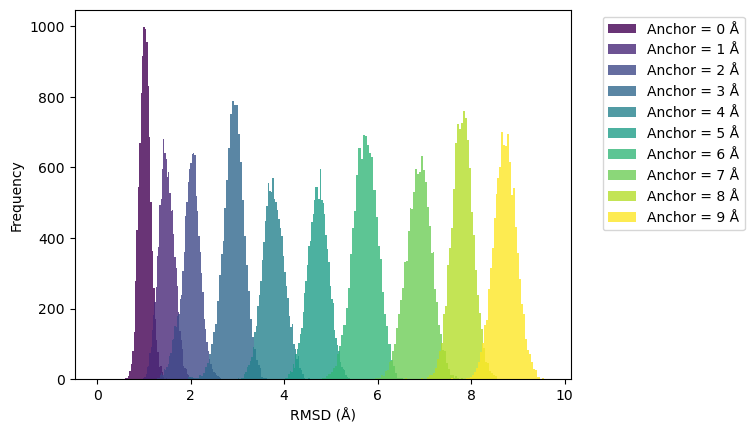

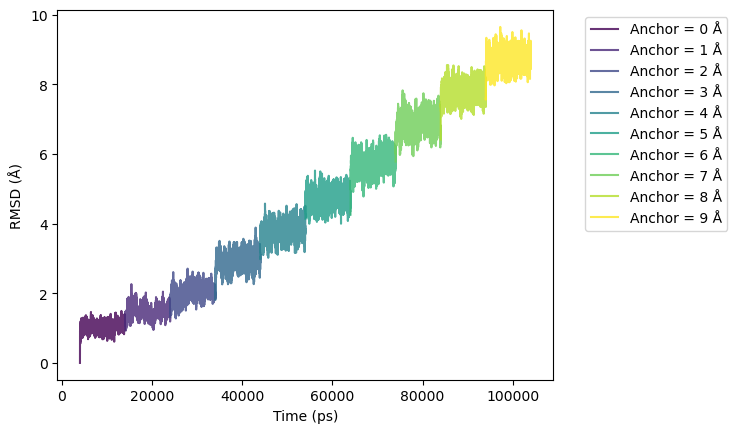

In [19]:
for df, label, color in zip(receptor_FSC_df_list, labels, colors):
    sns.histplot(df["Collective variable (1:1)"], bins=50, label=label, alpha=0.8, color=color, edgecolor='none')

plt.xlabel("RMSD (Å)")
plt.ylabel("Frequency")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

for df, label, color in zip(receptor_FSC_df_list, labels, colors):
    sns.lineplot(data=df, x="MD time (ps)", y="Collective variable (1:1)", label=label, alpha=0.8, color=color)

plt.xlabel("Time (ps)")
plt.ylabel("RMSD (Å)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

#### Receptor only
`B2/receptor/prod_colv_receptor_cluster`

In [20]:
colv0_receptor_path = 'B2/receptor/prod_colv_receptor/colv0.dat'
colv1_receptor_path = 'B2/receptor/prod_colv_receptor/colv1.dat'
colv2_receptor_path = 'B2/receptor/prod_colv_receptor/colv2.dat'
colv3_receptor_path = 'B2/receptor/prod_colv_receptor/colv3.dat'
colv4_receptor_path = 'B2/receptor/prod_colv_receptor/colv4.dat'
colv5_receptor_path = 'B2/receptor/prod_colv_receptor/colv5.dat'
colv6_receptor_path = 'B2/receptor/prod_colv_receptor/colv6.dat'
colv7_receptor_path = 'B2/receptor/prod_colv_receptor/colv7.dat'
colv8_receptor_path = 'B2/receptor/prod_colv_receptor/colv8.dat'
colv9_receptor_path = 'B2/receptor/prod_colv_receptor/colv9.dat'

column_names = ["MD time (ps)", "Collective variable (1:1)"]
colv0_receptor_df = pd.read_csv(colv0_receptor_path, comment='#', delim_whitespace=True, header=None, names=column_names)
display(colv0_receptor_df)

colv1_receptor_df = pd.read_csv(colv1_receptor_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv2_receptor_df = pd.read_csv(colv2_receptor_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv3_receptor_df = pd.read_csv(colv3_receptor_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv4_receptor_df = pd.read_csv(colv4_receptor_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv5_receptor_df = pd.read_csv(colv5_receptor_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv6_receptor_df = pd.read_csv(colv6_receptor_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv7_receptor_df = pd.read_csv(colv7_receptor_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv8_receptor_df = pd.read_csv(colv8_receptor_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv9_receptor_df = pd.read_csv(colv9_receptor_path, comment='#', delim_whitespace=True, header=None, names=column_names)

,MD time (ps),Collective variable (1:1)
0,4000.0,0.000472
1,4001.0,0.698241
2,4002.0,0.637628
3,4003.0,0.642202
4,4004.0,0.704442
...,...,...
9995,13995.0,1.293310
9996,13996.0,1.311340
9997,13997.0,1.224874
9998,13998.0,1.362410


In [21]:
receptor_df_list = [colv0_receptor_df, colv1_receptor_df, colv2_receptor_df, colv3_receptor_df, colv4_receptor_df, colv5_receptor_df, colv6_receptor_df, colv7_receptor_df, colv8_receptor_df, colv9_receptor_df]

colors = cmap(np.linspace(0, 1, len(receptor_df_list)))

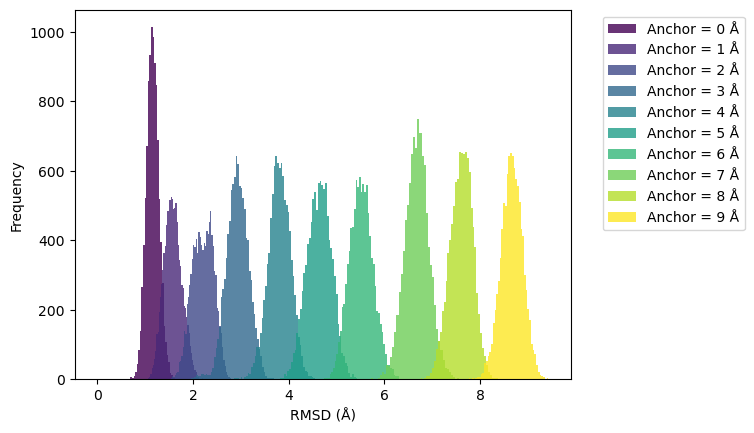

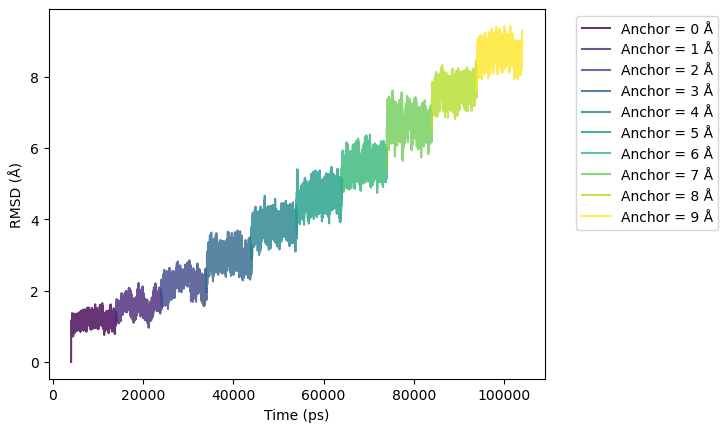

In [22]:
for df, label, color in zip(receptor_df_list, labels, colors):
    sns.histplot(df["Collective variable (1:1)"], bins=50, label=label, alpha=0.8, color=color, edgecolor='none')

plt.xlabel("RMSD (Å)")
plt.ylabel("Frequency")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

for df, label, color in zip(receptor_df_list, labels, colors):
    sns.lineplot(data=df, x="MD time (ps)", y="Collective variable (1:1)", label=label, alpha=0.8, color=color)

plt.xlabel("Time (ps)")
plt.ylabel("RMSD (Å)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

#### Free energy comparison
`wham 0 10 100 0.01 310 0 meta.dat result_bootstrap.dat 100 42`

In [6]:
colv_receptor_free_path = 'B2/receptor/prod_colv_receptor_cluster/result_bootstrap.dat'
colv_receptor_FSC_free_path = 'B2/receptor_FSC/prod_colv_receptor_FSC_cluster/result_bootstrap.dat'

# Read the data, skipping the first row (header), drop rows, filter 'inf' and convert columns to numeric
colv_receptor_free_df = (pd.read_csv(colv_receptor_free_path, delim_whitespace=True, skiprows=1, names=['Coor', 'Free', '+/-Free', 'Prob', '+/-Prob']).iloc[:100].replace('inf', np.nan).apply(pd.to_numeric))
display(colv_receptor_free_df)
colv_receptor_FSC_free_df = (pd.read_csv(colv_receptor_FSC_free_path, delim_whitespace=True, skiprows=1, names=['Coor', 'Free', '+/-Free', 'Prob', '+/-Prob']).iloc[:100].replace('inf', np.nan).apply(pd.to_numeric))
display(colv_receptor_FSC_free_df)

,Coor,Free,+/-Free,Prob,+/-Prob
0,0.05,17.720889,NaN,0.0,0.0
1,0.15,NaN,0.267794,0.0,0.0
2,0.25,NaN,NaN,0.0,0.0
3,0.35,NaN,NaN,0.0,0.0
4,0.45,NaN,NaN,0.0,0.0
...,...,...,...,...,...
95,9.55,NaN,NaN,0.0,0.0
96,9.65,NaN,NaN,0.0,0.0
97,9.75,NaN,NaN,0.0,0.0
98,9.85,NaN,NaN,0.0,0.0


,Coor,Free,+/-Free,Prob,+/-Prob
0,0.05,14.355181,NaN,0.0,0.0
1,0.15,NaN,NaN,0.0,0.0
2,0.25,NaN,NaN,0.0,0.0
3,0.35,NaN,NaN,0.0,0.0
4,0.45,NaN,NaN,0.0,0.0
...,...,...,...,...,...
95,9.55,13.113363,0.280258,0.0,0.0
96,9.65,13.614769,NaN,0.0,0.0
97,9.75,NaN,NaN,0.0,0.0
98,9.85,NaN,NaN,0.0,0.0


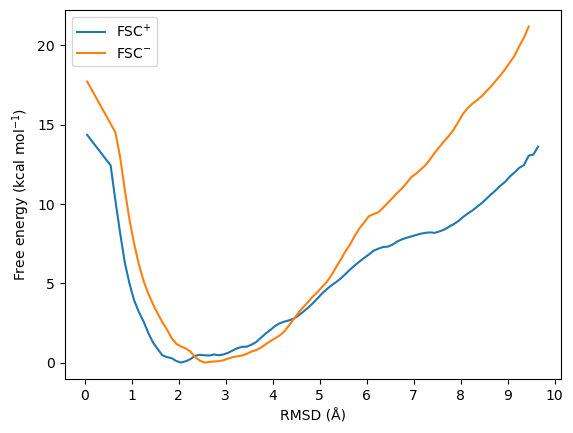

In [7]:
sns.lineplot(x='Coor', y='Free', data=colv_receptor_FSC_free_df, label='FSC$^{+}$')
sns.lineplot(x='Coor', y='Free', data=colv_receptor_free_df, label='FSC$^{-}$')
plt.xlabel('RMSD (Å)')
plt.ylabel('Free energy (kcal mol$^{-1}$)')
plt.xticks(np.arange(0, 11, step=1))
plt.show()

~~AGAINST hypothesis...~~\
Prof: FSC$^{+}$ being shifted to 0 is desired $\because$ it implies FSC "stabilizes" the receptor's interface more to the equilibrium structure

#### Integrate to find free energy difference in FSC presence

In [8]:
from scipy.integrate import quad
from scipy.interpolate import interp1d
import math

$$
\Delta G = -RT \ln{
\frac{
\int_{0}^{10}{
\left[ \exp \left[ -\frac{\beta}{N_A} G_{\text{RMSD}} \right] \exp \left[ -\frac{\beta k}{2 N_A} ( \text{RMSD} - \text{RMSD}_{\text{ref}} ) \right] \right] d(\text{RMSD})
                }
    }
    {
\int_{0}^{10}{
\exp \left[ -\frac{\beta}{N_A} G_{\text{RMSD}} \right] d(\text{RMSD})
            } 
    } 
                } 
$$

##### Set up constants

In [81]:
k_B = 1.380658e-23 # J/K
T = 310 # K
beta = 1 / ( k_B * T ) # /J
print(f"Boltzmann factor in joule: {beta} /J")

Boltzmann factor in joule: 2.336426871544512e+20 /J


In [52]:
Jtokcal = 4184 # J/kcal
beta_kcal = beta * Jtokcal  # /kcal
print(f"Boltzmann factor after conversion to kcal: {beta_kcal} /kcal")

Boltzmann factor after conversion to kcal: 9.775610030542242e+23 /kcal


$$
\frac{\beta}{N_A} = \hat{\beta}
$$

In [50]:
N_A = 6.0221367e+23 # /mol
beta_kcal_molar = beta_kcal / N_A # mol/kcal
print(f"Boltzmann factor after conversion to moles: {beta_kcal_molar} mol/kcal")

Boltzmann factor after conversion to moles: 1.623279330497802 mol/kcal


In [53]:
R = 8.3145112 # J/K/mol
R_kcal = R / conversion # kcal/K/mol
print(f"Gas constant after conversion to kcal: {R_kcal} kcal/K/mol")

Gas constant after conversion to kcal: 0.0019872158699808795 kcal/K/mol


Harmonic (spring) constant and reference conformation

In [71]:
k = 10 # kcal/mol/Å^2
RMSD_ref = 0 # Å (i.e., crystal structure)

##### Tutorial on numerical integration

Learn function interpolation

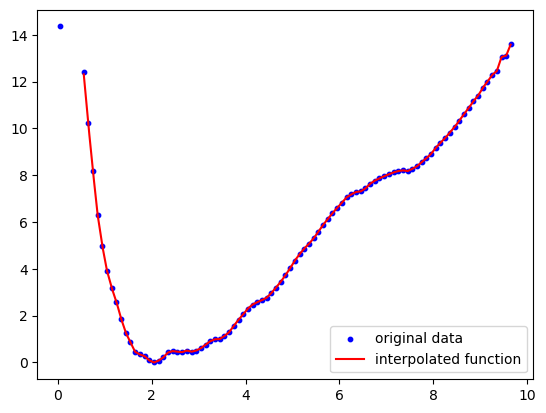

In [34]:
# Create an interpolation function for G_RMSD
G_RMSD = interp1d(colv_receptor_FSC_free_df['Coor'], colv_receptor_FSC_free_df['Free'])
    
# Define a range of input values
x_new = np.linspace(colv_receptor_FSC_free_df['Coor'].min(), colv_receptor_FSC_free_df['Coor'].max(), num=1000, endpoint=True)

# Compute the interpolated values
y_new = G_RMSD(x_new)

# Plot the original data
plt.scatter(colv_receptor_FSC_free_df['Coor'], colv_receptor_FSC_free_df['Free'], s=10, c='b', label='original data')

# Plot the interpolated function
plt.plot(x_new, y_new, '-', c='r', label='interpolated function')

plt.legend()
plt.show()

Learn `scipy.integrate.quad()`

In [35]:
from scipy.integrate import quad
import numpy as np

# Define a simple function to integrate
def f(x):
    return np.sin(x)

# Integrate the function from 0 to pi
integral, error = quad(f, 0, np.pi)

print("Integral:", integral)
print("Estimated error:", error)

Integral: 2.0
Estimated error: 2.220446049250313e-14


##### FSC$^{+}$
Tutorial: integrate each term

In [58]:
display(colv_receptor_FSC_free_df)
# Drop rows with NaN values in 'Free' column
colv_receptor_FSC_free_dropna_df = colv_receptor_FSC_free_df.dropna(subset=['Free'])
display(colv_receptor_FSC_free_dropna_df)

,Coor,Free,+/-Free,Prob,+/-Prob
0,0.05,14.355181,NaN,0.0,0.0
1,0.15,NaN,NaN,0.0,0.0
2,0.25,NaN,NaN,0.0,0.0
3,0.35,NaN,NaN,0.0,0.0
4,0.45,NaN,NaN,0.0,0.0
...,...,...,...,...,...
95,9.55,13.113363,0.280258,0.0,0.0
96,9.65,13.614769,NaN,0.0,0.0
97,9.75,NaN,NaN,0.0,0.0
98,9.85,NaN,NaN,0.0,0.0


,Coor,Free,+/-Free,Prob,+/-Prob
0,0.05,14.355181,NaN,0.000000,0.0
5,0.55,12.429109,NaN,0.000000,0.0
6,0.65,10.229259,0.139846,0.000000,0.0
7,0.75,8.199389,0.050069,0.000000,0.0
8,0.85,6.318042,0.028692,0.000003,0.0
...,...,...,...,...,...
92,9.25,12.283609,0.090715,0.000000,0.0
93,9.35,12.452640,0.096437,0.000000,0.0
94,9.45,13.050114,0.187003,0.000000,0.0
95,9.55,13.113363,0.280258,0.000000,0.0


Create an interpolation function for G_RMSD

In [83]:
G_RMSD_FSC = interp1d(colv_receptor_FSC_free_dropna_df['Coor'], colv_receptor_FSC_free_dropna_df['Free'])

In [84]:
def integrand_denom(RMSD):
    return np.exp(-beta_kcal_molar * G_RMSD_FSC(RMSD))

integral_denom, error_denom = quad(integrand_denom, colv_receptor_FSC_free_dropna_df['Coor'].min(), colv_receptor_FSC_free_dropna_df['Coor'].max())

print("Integral:", integral_denom)
print("Estimated error:", error_denom)

Integral: 1.0624852879170565
Estimated error: 0.0004809151575402293


/home/wjoon21/anaconda3/envs/ppis/lib/python3.7/site-packages/ipykernel_launcher.py:4: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  after removing the cwd from sys.path.


initially missed the `-` before `beta_kcal_molar`\
$\rightarrow$ obtained WRONG `delta_G_FSC` value to the _correct_ combined function approach below (FSC$^{-}$)\
$\rightarrow$ FIXED

In [85]:
def integrand_num(RMSD):
    return np.exp(-beta_kcal_molar * G_RMSD(RMSD)) * np.exp(-0.5 * beta_kcal_molar * k * (RMSD - RMSD_ref)**2)

integral_num, error_num = quad(integrand_num, colv_receptor_FSC_free_dropna_df['Coor'].min(), colv_receptor_FSC_free_dropna_df['Coor'].max())

print("Integral:", integral_num)
print("Estimated error:", error_num)

Integral: 7.110323403747354e-08
Estimated error: 1.1192690879827496e-09


In [86]:
ratio_integral = integral_num / integral_denom
print("Ratio of integrals:", ratio_integral)

Ratio of integrals: 6.69216175001044e-08


In [87]:
delta_G_FSC = - R_kcal * T * math.log( ratio_integral )
print(f"Free energy difference: {delta_G_FSC} kcal/mol")

Free energy difference: 10.176772078814457 kcal/mol


##### FSC$^{-}$
Implemented in function

In [77]:
def compute_delta_G(df, boltzmann_factor_kcal_molar, harmonic_constant_kcal, reference_rmsd, gas_constant_kcal, temperature):
    # Drop rows with NaN values in 'Free' column
    df_dropna = df.dropna(subset=['Free'])

    # Create an interpolation function for G_RMSD
    G_RMSD = interp1d(df_dropna['Coor'], df_dropna['Free'])

    # Define the integrand for the numerator
    def integrand_numerator(RMSD):
        return np.exp(-boltzmann_factor_kcal_molar * G_RMSD(RMSD)) * np.exp(
            -0.5 * boltzmann_factor_kcal_molar * harmonic_constant_kcal * (RMSD - reference_rmsd)**2)

    # Define the integrand for the denominator
    def integrand_denominator(RMSD):
        return np.exp(-boltzmann_factor_kcal_molar * G_RMSD(RMSD))

    # Compute the integrals
    integral_numerator, _ = quad(integrand_numerator, df_dropna['Coor'].min(), df_dropna['Coor'].max())
    integral_denominator, _ = quad(integrand_denominator, df_dropna['Coor'].min(), df_dropna['Coor'].max())

    # Compute delta G
    delta_G = - gas_constant_kcal * temperature * math.log( integral_numerator / integral_denominator )

    return delta_G

In [78]:
delta_G_noFSC = compute_delta_G(colv_receptor_free_df, beta_kcal_molar, k, RMSD_ref, R_kcal, T)
print(f"Free energy difference: {delta_G_noFSC} kcal/mol")

Free energy difference: 13.567328234921291 kcal/mol


/home/wjoon21/anaconda3/envs/ppis/lib/python3.7/site-packages/ipykernel_launcher.py:19: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.


Try function on FSC$^{+}$

In [80]:
delta_G_FSC1 = compute_delta_G(colv_receptor_FSC_free_df, beta_kcal_molar, k, RMSD_ref, R_kcal, T)
print(f"Free energy difference: {delta_G_FSC1} kcal/mol")

Free energy difference: 10.176772078814457 kcal/mol


/home/wjoon21/anaconda3/envs/ppis/lib/python3.7/site-packages/ipykernel_launcher.py:19: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.


##### Add free energy errors

In [89]:
def compute_delta_G_error(df, boltzmann_factor_kcal_molar, harmonic_constant_kcal, reference_rmsd, gas_constant_kcal, temperature):
    # Drop rows with NaN values in 'Free' column
    df_dropna = df.dropna(subset=['Free'])

    # Create an interpolation function for G_RMSD
    G_RMSD = interp1d(df_dropna['Coor'], df_dropna['Free'])

    # Define the integrand for the numerator
    def integrand_numerator(RMSD):
        return np.exp(-boltzmann_factor_kcal_molar * G_RMSD(RMSD)) * np.exp(
            -0.5 * boltzmann_factor_kcal_molar * harmonic_constant_kcal * (RMSD - reference_rmsd)**2)

    # Define the integrand for the denominator
    def integrand_denominator(RMSD):
        return np.exp(-boltzmann_factor_kcal_molar * G_RMSD(RMSD))

    # Compute the integrals
    integral_numerator, error_numerator = quad(integrand_numerator, df_dropna['Coor'].min(), df_dropna['Coor'].max())
    integral_denominator, error_denominator = quad(integrand_denominator, df_dropna['Coor'].min(), df_dropna['Coor'].max())

    # Compute delta G
    delta_G = - gas_constant_kcal * temperature * math.log( integral_numerator / integral_denominator )

    # Compute the error in delta G
    delta_G_error = gas_constant_kcal * temperature * math.sqrt((error_numerator / integral_numerator)**2 + (error_denominator / integral_denominator)**2)

    return delta_G, delta_G_error

In [91]:
delta_G_FSC, error_delta_G_FSC = compute_delta_G_error(colv_receptor_FSC_free_df, beta_kcal_molar, k, RMSD_ref, R_kcal, T)
print(f"Free energy difference with FSC: {delta_G_FSC1} +/- {error_delta_G_FSC} kcal/mol")

delta_G_noFSC, error_delta_G_noFSC = compute_delta_G_error(colv_receptor_free_df, beta_kcal_molar, k, RMSD_ref, R_kcal, T)
print(f"Free energy difference without FSC: {delta_G_noFSC} +/- {error_delta_G_noFSC} kcal/mol")

Free energy difference with FSC: 10.176772078814457 +/- 0.009701331814124766 kcal/mol
Free energy difference without FSC: 13.567328234921291 +/- 1.0435045369135878 kcal/mol


/home/wjoon21/anaconda3/envs/ppis/lib/python3.7/site-packages/ipykernel_launcher.py:19: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.


### Replicate 2
local machine
1. GTX 1070
2. AMBER22
3. `iwrap=1`

#### Receptor + FSC
`B2/receptor_FSC/prod_colv_receptor_FSC_local`

In [4]:
colv0_receptor_FSC_local_path = 'B2/receptor_FSC/prod_colv_receptor_FSC_local/colv0.dat'
colv1_receptor_FSC_local_path = 'B2/receptor_FSC/prod_colv_receptor_FSC_local/colv1.dat'
colv2_receptor_FSC_local_path = 'B2/receptor_FSC/prod_colv_receptor_FSC_local/colv2.dat'
colv3_receptor_FSC_local_path = 'B2/receptor_FSC/prod_colv_receptor_FSC_local/colv3.dat'
colv4_receptor_FSC_local_path = 'B2/receptor_FSC/prod_colv_receptor_FSC_local/colv4.dat'
colv5_receptor_FSC_local_path = 'B2/receptor_FSC/prod_colv_receptor_FSC_local/colv5.dat'
colv6_receptor_FSC_local_path = 'B2/receptor_FSC/prod_colv_receptor_FSC_local/colv6.dat'
colv7_receptor_FSC_local_path = 'B2/receptor_FSC/prod_colv_receptor_FSC_local/colv7.dat'
colv8_receptor_FSC_local_path = 'B2/receptor_FSC/prod_colv_receptor_FSC_local/colv8.dat'
colv9_receptor_FSC_local_path = 'B2/receptor_FSC/prod_colv_receptor_FSC_local/colv9.dat'

colv0_receptor_FSC_local_df = pd.read_csv(colv0_receptor_FSC_local_path, comment='#', delim_whitespace=True, header=None, names=column_names)
display(colv0_receptor_FSC_local_df)

colv1_receptor_FSC_local_df = pd.read_csv(colv1_receptor_FSC_local_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv2_receptor_FSC_local_df = pd.read_csv(colv2_receptor_FSC_local_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv3_receptor_FSC_local_df = pd.read_csv(colv3_receptor_FSC_local_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv4_receptor_FSC_local_df = pd.read_csv(colv4_receptor_FSC_local_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv5_receptor_FSC_local_df = pd.read_csv(colv5_receptor_FSC_local_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv6_receptor_FSC_local_df = pd.read_csv(colv6_receptor_FSC_local_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv7_receptor_FSC_local_df = pd.read_csv(colv7_receptor_FSC_local_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv8_receptor_FSC_local_df = pd.read_csv(colv8_receptor_FSC_local_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv9_receptor_FSC_local_df = pd.read_csv(colv9_receptor_FSC_local_path, comment='#', delim_whitespace=True, header=None, names=column_names)

,MD time (ps),Collective variable (1:1)
0,4000.0,0.000506
1,4001.0,0.547473
2,4002.0,0.530294
3,4003.0,0.519506
4,4004.0,0.609450
...,...,...
9995,13995.0,0.955526
9996,13996.0,0.874313
9997,13997.0,0.954702
9998,13998.0,0.952118


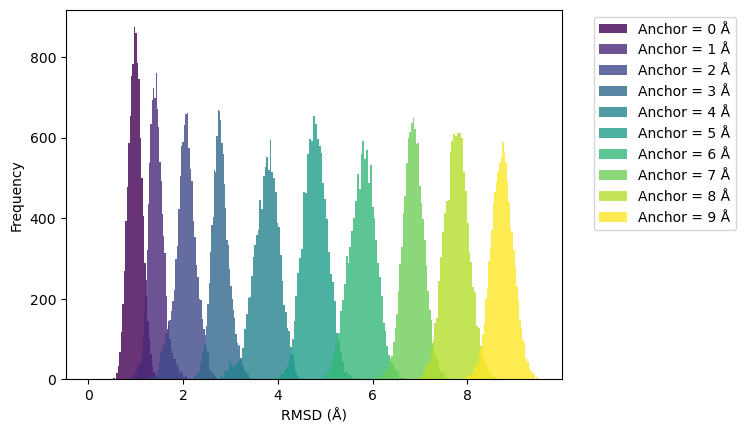

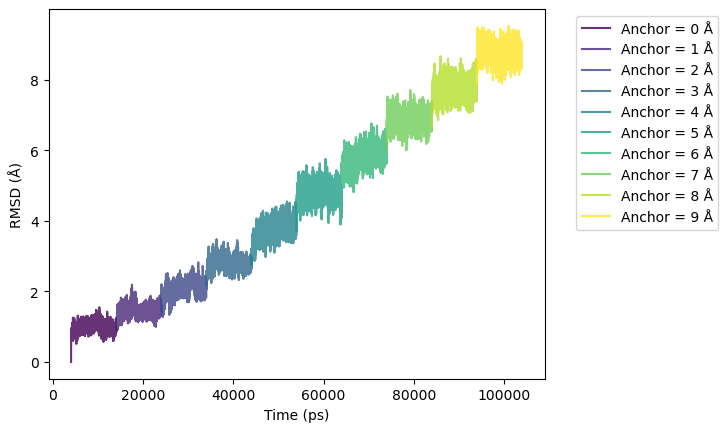

In [6]:
receptor_FSC_df_list = [colv0_receptor_FSC_local_df, colv1_receptor_FSC_local_df, colv2_receptor_FSC_local_df, colv3_receptor_FSC_local_df, colv4_receptor_FSC_local_df, colv5_receptor_FSC_local_df, colv6_receptor_FSC_local_df, colv7_receptor_FSC_local_df, colv8_receptor_FSC_local_df, colv9_receptor_FSC_local_df]

colors = cmap(np.linspace(0, 1, len(receptor_FSC_df_list)))

for df, label, color in zip(receptor_FSC_df_list, labels, colors):
    sns.histplot(df["Collective variable (1:1)"], bins=50, label=label, alpha=0.8, color=color, edgecolor='none')

plt.xlabel("RMSD (Å)")
plt.ylabel("Frequency")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

for df, label, color in zip(receptor_FSC_df_list, labels, colors):
    sns.lineplot(data=df, x="MD time (ps)", y="Collective variable (1:1)", label=label, alpha=0.8, color=color)

plt.xlabel("Time (ps)")
plt.ylabel("RMSD (Å)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

#### Receptor
`B2/receptor/prod_colv_receptor_local`

In [8]:
colv0_receptor_local_path = 'B2/receptor/prod_colv_receptor_local/colv0.dat'
colv1_receptor_local_path = 'B2/receptor/prod_colv_receptor_local/colv1.dat'
colv2_receptor_local_path = 'B2/receptor/prod_colv_receptor_local/colv2.dat'
colv3_receptor_local_path = 'B2/receptor/prod_colv_receptor_local/colv3.dat'
colv4_receptor_local_path = 'B2/receptor/prod_colv_receptor_local/colv4.dat'
colv5_receptor_local_path = 'B2/receptor/prod_colv_receptor_local/colv5.dat'
colv6_receptor_local_path = 'B2/receptor/prod_colv_receptor_local/colv6.dat'
colv7_receptor_local_path = 'B2/receptor/prod_colv_receptor_local/colv7.dat'
colv8_receptor_local_path = 'B2/receptor/prod_colv_receptor_local/colv8.dat'
colv9_receptor_local_path = 'B2/receptor/prod_colv_receptor_local/colv9.dat'

colv0_receptor_local_df = pd.read_csv(colv0_receptor_local_path, comment='#', delim_whitespace=True, header=None, names=column_names)
display(colv0_receptor_local_df)

colv1_receptor_local_df = pd.read_csv(colv1_receptor_local_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv2_receptor_local_df = pd.read_csv(colv2_receptor_local_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv3_receptor_local_df = pd.read_csv(colv3_receptor_local_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv4_receptor_local_df = pd.read_csv(colv4_receptor_local_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv5_receptor_local_df = pd.read_csv(colv5_receptor_local_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv6_receptor_local_df = pd.read_csv(colv6_receptor_local_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv7_receptor_local_df = pd.read_csv(colv7_receptor_local_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv8_receptor_local_df = pd.read_csv(colv8_receptor_local_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv9_receptor_local_df = pd.read_csv(colv9_receptor_local_path, comment='#', delim_whitespace=True, header=None, names=column_names)

,MD time (ps),Collective variable (1:1)
0,4000.0,0.000472
1,4001.0,0.556887
2,4002.0,0.589122
3,4003.0,0.573394
4,4004.0,0.653973
...,...,...
9995,13995.0,1.320245
9996,13996.0,1.257740
9997,13997.0,1.287521
9998,13998.0,1.235308


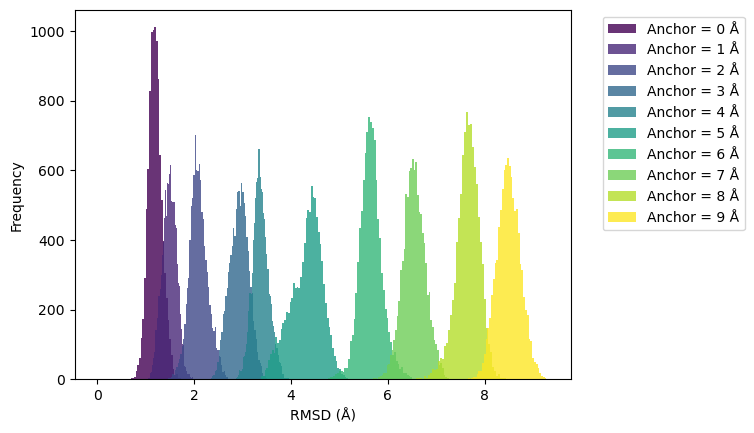

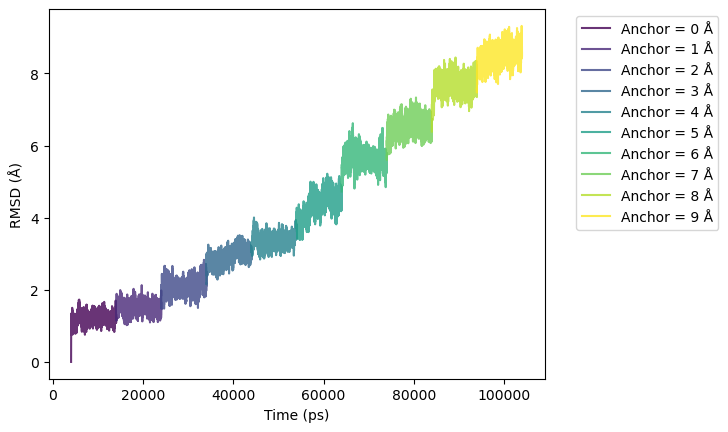

In [9]:
receptor_df_list = [colv0_receptor_local_df, colv1_receptor_local_df, colv2_receptor_local_df, colv3_receptor_local_df, colv4_receptor_local_df, colv5_receptor_local_df, colv6_receptor_local_df, colv7_receptor_local_df, colv8_receptor_local_df, colv9_receptor_local_df]

colors = cmap(np.linspace(0, 1, len(receptor_df_list)))

for df, label, color in zip(receptor_df_list, labels, colors):
    sns.histplot(df["Collective variable (1:1)"], bins=50, label=label, alpha=0.8, color=color, edgecolor='none')

plt.xlabel("RMSD (Å)")
plt.ylabel("Frequency")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

for df, label, color in zip(receptor_df_list, labels, colors):
    sns.lineplot(data=df, x="MD time (ps)", y="Collective variable (1:1)", label=label, alpha=0.8, color=color)

plt.xlabel("Time (ps)")
plt.ylabel("RMSD (Å)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

#### Free energy comparison

In [3]:
colv_receptor_local_free_path = 'B2/receptor/prod_colv_receptor_local/result_bootstrap.dat'
colv_receptor_FSC_local_free_path = 'B2/receptor_FSC/prod_colv_receptor_FSC_local/result_bootstrap.dat'

# Read the data, skipping the first row (header), drop rows, filter 'inf' and convert columns to numeric
colv_receptor_local_free_df = (pd.read_csv(colv_receptor_local_free_path, delim_whitespace=True, skiprows=1, names=['Coor', 'Free', '+/-Free', 'Prob', '+/-Prob']).iloc[:100].replace('inf', np.nan).apply(pd.to_numeric))
display(colv_receptor_local_free_df)
colv_receptor_FSC_local_free_df = (pd.read_csv(colv_receptor_FSC_local_free_path, delim_whitespace=True, skiprows=1, names=['Coor', 'Free', '+/-Free', 'Prob', '+/-Prob']).iloc[:100].replace('inf', np.nan).apply(pd.to_numeric))
display(colv_receptor_FSC_local_free_df)

,Coor,Free,+/-Free,Prob,+/-Prob
0,0.05,16.273205,NaN,0.0,0.0
1,0.15,NaN,NaN,0.0,0.0
2,0.25,NaN,NaN,0.0,0.0
3,0.35,NaN,NaN,0.0,0.0
4,0.45,NaN,NaN,0.0,0.0
...,...,...,...,...,...
95,9.55,NaN,NaN,0.0,0.0
96,9.65,NaN,NaN,0.0,0.0
97,9.75,NaN,NaN,0.0,0.0
98,9.85,NaN,NaN,0.0,0.0


,Coor,Free,+/-Free,Prob,+/-Prob
0,0.05,14.162586,NaN,0.0,0.0
1,0.15,NaN,0.165406,0.0,0.0
2,0.25,NaN,NaN,0.0,0.0
3,0.35,NaN,NaN,0.0,0.0
4,0.45,NaN,NaN,0.0,0.0
...,...,...,...,...,...
95,9.55,14.677681,NaN,0.0,0.0
96,9.65,NaN,NaN,0.0,0.0
97,9.75,NaN,NaN,0.0,0.0
98,9.85,NaN,NaN,0.0,0.0


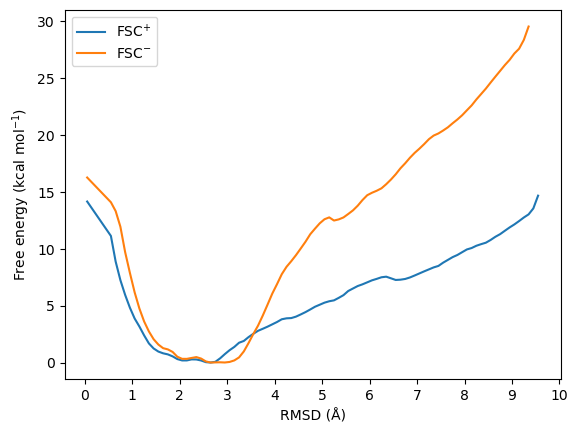

In [4]:
sns.lineplot(x='Coor', y='Free', data=colv_receptor_FSC_local_free_df, label='FSC$^{+}$')
sns.lineplot(x='Coor', y='Free', data=colv_receptor_local_free_df, label='FSC$^{-}$')
plt.xlabel('RMSD (Å)')
plt.ylabel('Free energy (kcal mol$^{-1}$)')
plt.xticks(np.arange(0, 11, step=1))
plt.show()

~~again AGAINST hypothesis...~~

#### Integrate to find free energy difference

In [79]:
delta_G_FSC2 = compute_delta_G(colv_receptor_FSC_local_free_df, beta_kcal_molar, k, RMSD_ref, R_kcal, T)
print(f"Free energy difference with FSC: {delta_G_FSC2} kcal/mol")
delta_G_noFSC2 = compute_delta_G(colv_receptor_local_free_df, beta_kcal_molar, k, RMSD_ref, R_kcal, T)
print(f"Free energy difference without FSC: {delta_G_noFSC2} kcal/mol")

Free energy difference with FSC: 9.916860624363094 kcal/mol
Free energy difference without FSC: 12.141917503766859 kcal/mol


/home/wjoon21/anaconda3/envs/ppis/lib/python3.7/site-packages/ipykernel_launcher.py:19: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.


In [92]:
delta_G_FSC2, error_delta_G_FSC2 = compute_delta_G_error(colv_receptor_FSC_local_free_df, beta_kcal_molar, k, RMSD_ref, R_kcal, T)
print(f"Free energy difference with FSC: {delta_G_FSC2} +/- {error_delta_G_FSC2} kcal/mol")
delta_G_noFSC2, error_delta_G_FSC2 = compute_delta_G_error(colv_receptor_local_free_df, beta_kcal_molar, k, RMSD_ref, R_kcal, T)
print(f"Free energy difference without FSC: {delta_G_noFSC2} +/- {error_delta_G_FSC2} kcal/mol")

Free energy difference with FSC: 9.916860624363094 +/- 0.015922614751596877 kcal/mol
Free energy difference without FSC: 12.141917503766859 +/- 1.0571540000474053 kcal/mol


/home/wjoon21/anaconda3/envs/ppis/lib/python3.7/site-packages/ipykernel_launcher.py:19: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.


### $\therefore$ FSC$^{+}$ systems have lower free energy changes in receptor interface
Replicates 1 & 2 show same trend

"Easier" to shift system with FSC (FSC$^{+}$) to the equilibrated conformation?\
$\Leftrightarrow$ FSC stabilizes the receptor?\
$\Leftrightarrow$ FSC makes it more favourable for the receptor to be in a ligand-binding conformation?

### (NG) Replicate 3
1. `iwrap=0` `trial1`
2. GTX TITAN X

#### FSC$^{+}$
`B2/receptor_FSC/prod_colv_iwrap0_dat/trial1`

In [17]:
colv0_FSC_iwrap0_t1_path = 'B2/receptor_FSC/prod_colv_iwrap0_dat/trial1/colv0.dat'
colv1_FSC_iwrap0_t1_path = 'B2/receptor_FSC/prod_colv_iwrap0_dat/trial1/colv1.dat'
colv2_FSC_iwrap0_t1_path = 'B2/receptor_FSC/prod_colv_iwrap0_dat/trial1/colv2.dat'
colv3_FSC_iwrap0_t1_path = 'B2/receptor_FSC/prod_colv_iwrap0_dat/trial1/colv3.dat'
colv4_FSC_iwrap0_t1_path = 'B2/receptor_FSC/prod_colv_iwrap0_dat/trial1/colv4.dat'
colv5_FSC_iwrap0_t1_path = 'B2/receptor_FSC/prod_colv_iwrap0_dat/trial1/colv5.dat'
colv6_FSC_iwrap0_t1_path = 'B2/receptor_FSC/prod_colv_iwrap0_dat/trial1/colv6.dat'
colv7_FSC_iwrap0_t1_path = 'B2/receptor_FSC/prod_colv_iwrap0_dat/trial1/colv7.dat'
colv8_FSC_iwrap0_t1_path = 'B2/receptor_FSC/prod_colv_iwrap0_dat/trial1/colv8.dat'
colv9_FSC_iwrap0_t1_path = 'B2/receptor_FSC/prod_colv_iwrap0_dat/trial1/colv9.dat'

colv0_FSC_iwrap0_t1_df = pd.read_csv(colv0_FSC_iwrap0_t1_path, comment='#', delim_whitespace=True, header=None, names=column_names)
display(colv0_FSC_iwrap0_t1_df)

colv1_FSC_iwrap0_t1_df = pd.read_csv(colv1_FSC_iwrap0_t1_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv2_FSC_iwrap0_t1_df = pd.read_csv(colv2_FSC_iwrap0_t1_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv3_FSC_iwrap0_t1_df = pd.read_csv(colv3_FSC_iwrap0_t1_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv4_FSC_iwrap0_t1_df = pd.read_csv(colv4_FSC_iwrap0_t1_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv5_FSC_iwrap0_t1_df = pd.read_csv(colv5_FSC_iwrap0_t1_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv6_FSC_iwrap0_t1_df = pd.read_csv(colv6_FSC_iwrap0_t1_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv7_FSC_iwrap0_t1_df = pd.read_csv(colv7_FSC_iwrap0_t1_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv8_FSC_iwrap0_t1_df = pd.read_csv(colv8_FSC_iwrap0_t1_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv9_FSC_iwrap0_t1_df = pd.read_csv(colv9_FSC_iwrap0_t1_path, comment='#', delim_whitespace=True, header=None, names=column_names)

,MD time (ps),Collective variable (1:1)
0,4000.0,0.000506
1,4001.0,0.647893
2,4002.0,0.633670
3,4003.0,0.782691
4,4004.0,0.653083
...,...,...
9995,13995.0,0.971110
9996,13996.0,0.942710
9997,13997.0,0.988339
9998,13998.0,0.954970


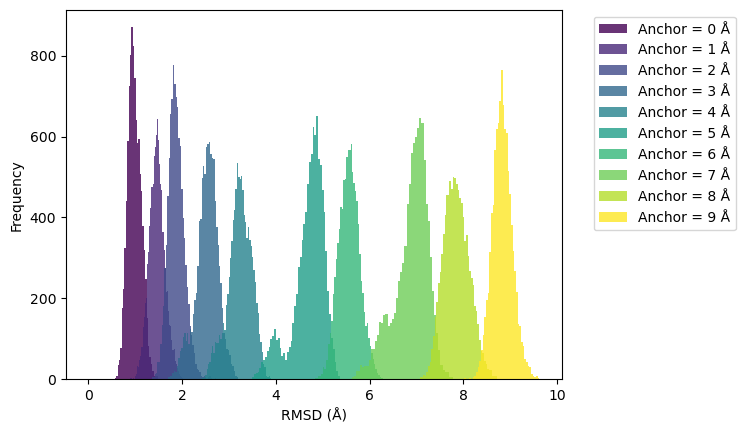

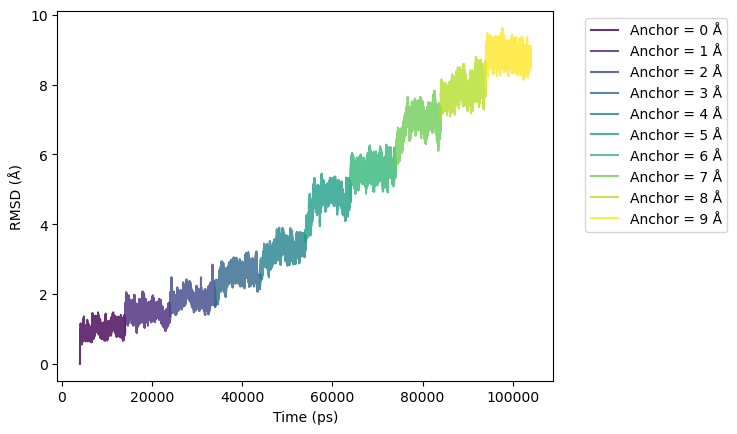

In [18]:
df_list = [colv0_FSC_iwrap0_t1_df, colv1_FSC_iwrap0_t1_df, colv2_FSC_iwrap0_t1_df, colv3_FSC_iwrap0_t1_df, colv4_FSC_iwrap0_t1_df, colv5_FSC_iwrap0_t1_df, colv6_FSC_iwrap0_t1_df, colv7_FSC_iwrap0_t1_df, colv8_FSC_iwrap0_t1_df, colv9_FSC_iwrap0_t1_df]

colors = cmap(np.linspace(0, 1, len(df_list)))

for df, label, color in zip(df_list, labels, colors):
    sns.histplot(df["Collective variable (1:1)"], bins=50, label=label, alpha=0.8, color=color, edgecolor='none')

plt.xlabel("RMSD (Å)")
plt.ylabel("Frequency")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

for df, label, color in zip(df_list, labels, colors):
    sns.lineplot(data=df, x="MD time (ps)", y="Collective variable (1:1)", label=label, alpha=0.8, color=color)

plt.xlabel("Time (ps)")
plt.ylabel("RMSD (Å)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

#### (NG) FSC$^{-}$
`B2/receptor/prod_colv_iwrap0_dat/trial1`

WRONG `colv*.in` coordinates (used FSC$^{+}$ values $\because$ copied from FSC$^{+}$ run directory?)

In [15]:
colv0_iwrap0_t1_path = 'B2/receptor/prod_colv_iwrap0_dat/trial1/colv0.dat'
colv1_iwrap0_t1_path = 'B2/receptor/prod_colv_iwrap0_dat/trial1/colv1.dat'
colv2_iwrap0_t1_path = 'B2/receptor/prod_colv_iwrap0_dat/trial1/colv2.dat'
colv3_iwrap0_t1_path = 'B2/receptor/prod_colv_iwrap0_dat/trial1/colv3.dat'
colv4_iwrap0_t1_path = 'B2/receptor/prod_colv_iwrap0_dat/trial1/colv4.dat'
colv5_iwrap0_t1_path = 'B2/receptor/prod_colv_iwrap0_dat/trial1/colv5.dat'
colv6_iwrap0_t1_path = 'B2/receptor/prod_colv_iwrap0_dat/trial1/colv6.dat'
colv7_iwrap0_t1_path = 'B2/receptor/prod_colv_iwrap0_dat/trial1/colv7.dat'
colv8_iwrap0_t1_path = 'B2/receptor/prod_colv_iwrap0_dat/trial1/colv8.dat'
colv9_iwrap0_t1_path = 'B2/receptor/prod_colv_iwrap0_dat/trial1/colv9.dat'

colv0_iwrap0_t1_df = pd.read_csv(colv0_iwrap0_t1_path, comment='#', delim_whitespace=True, header=None, names=column_names)
display(colv0_iwrap0_t1_df)

colv1_iwrap0_t1_df = pd.read_csv(colv1_iwrap0_t1_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv2_iwrap0_t1_df = pd.read_csv(colv2_iwrap0_t1_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv3_iwrap0_t1_df = pd.read_csv(colv3_iwrap0_t1_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv4_iwrap0_t1_df = pd.read_csv(colv4_iwrap0_t1_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv5_iwrap0_t1_df = pd.read_csv(colv5_iwrap0_t1_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv6_iwrap0_t1_df = pd.read_csv(colv6_iwrap0_t1_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv7_iwrap0_t1_df = pd.read_csv(colv7_iwrap0_t1_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv8_iwrap0_t1_df = pd.read_csv(colv8_iwrap0_t1_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv9_iwrap0_t1_df = pd.read_csv(colv9_iwrap0_t1_path, comment='#', delim_whitespace=True, header=None, names=column_names)

,MD time (ps),Collective variable (1:1)
0,4000.0,1.740392
1,4001.0,1.727328
2,4002.0,1.633006
3,4003.0,1.624178
4,4004.0,1.669377
...,...,...
9995,13995.0,1.259368
9996,13996.0,1.264181
9997,13997.0,1.393637
9998,13998.0,1.413654


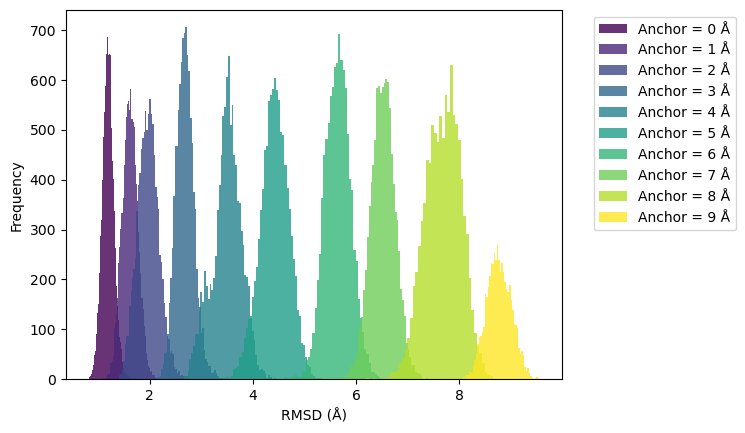

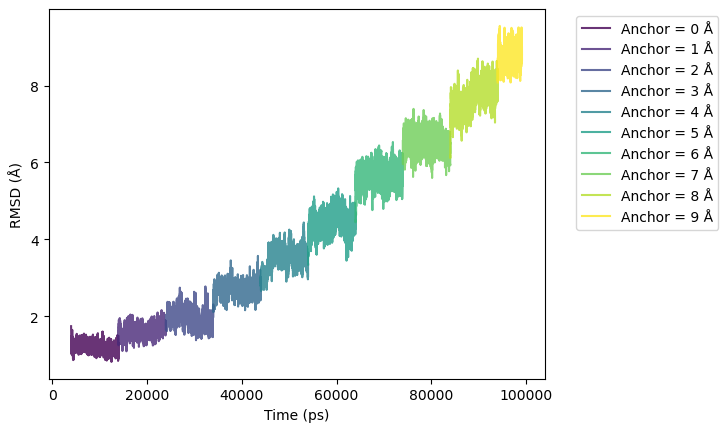

In [16]:
df_list = [colv0_iwrap0_t1_df, colv1_iwrap0_t1_df, colv2_iwrap0_t1_df, colv3_iwrap0_t1_df, colv4_iwrap0_t1_df, colv5_iwrap0_t1_df, colv6_iwrap0_t1_df, colv7_iwrap0_t1_df, colv8_iwrap0_t1_df, colv9_iwrap0_t1_df]

colors = cmap(np.linspace(0, 1, len(df_list)))

for df, label, color in zip(df_list, labels, colors):
    sns.histplot(df["Collective variable (1:1)"], bins=50, label=label, alpha=0.8, color=color, edgecolor='none')

plt.xlabel("RMSD (Å)")
plt.ylabel("Frequency")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

for df, label, color in zip(df_list, labels, colors):
    sns.lineplot(data=df, x="MD time (ps)", y="Collective variable (1:1)", label=label, alpha=0.8, color=color)

plt.xlabel("Time (ps)")
plt.ylabel("RMSD (Å)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

#### (NG) Free energy comparison
seems like wrong starting coordinates lead to "shifted" free energy curve?

In [19]:
colv_FSC_iwrap0_t1_free_path = 'B2/receptor_FSC/prod_colv_iwrap0_dat/trial1/result_bootstrap.dat'
colv_iwrap0_t1_free_path = 'B2/receptor/prod_colv_iwrap0_dat/trial1/result_bootstrap.dat'

colv_FSC_iwrap0_t1_free_df = (pd.read_csv(colv_FSC_iwrap0_t1_free_path, delim_whitespace=True, skiprows=1, names=['Coor', 'Free', '+/-Free', 'Prob', '+/-Prob']).iloc[:100].replace('inf', np.nan).apply(pd.to_numeric))
display(colv_FSC_iwrap0_t1_free_df)

colv_iwrap0_t1_free_df = (pd.read_csv(colv_iwrap0_t1_free_path, delim_whitespace=True, skiprows=1, names=['Coor', 'Free', '+/-Free', 'Prob', '+/-Prob']).iloc[:100].replace('inf', np.nan).apply(pd.to_numeric))
display(colv_iwrap0_t1_free_df)

,Coor,Free,+/-Free,Prob,+/-Prob
0,0.05,13.904511,NaN,0.0,0.0
1,0.15,NaN,0.291689,0.0,0.0
2,0.25,NaN,NaN,0.0,0.0
3,0.35,NaN,NaN,0.0,0.0
4,0.45,NaN,NaN,0.0,0.0
...,...,...,...,...,...
95,9.55,26.287007,0.180423,0.0,0.0
96,9.65,27.070890,NaN,0.0,0.0
97,9.75,NaN,NaN,0.0,0.0
98,9.85,NaN,NaN,0.0,0.0


,Coor,Free,+/-Free,Prob,+/-Prob
0,0.05,NaN,NaN,0.0,0.0
1,0.15,NaN,NaN,0.0,0.0
2,0.25,NaN,NaN,0.0,0.0
3,0.35,NaN,NaN,0.0,0.0
4,0.45,NaN,NaN,0.0,0.0
...,...,...,...,...,...
95,9.55,26.925717,0.270885,0.0,0.0
96,9.65,NaN,NaN,0.0,0.0
97,9.75,NaN,NaN,0.0,0.0
98,9.85,NaN,NaN,0.0,0.0


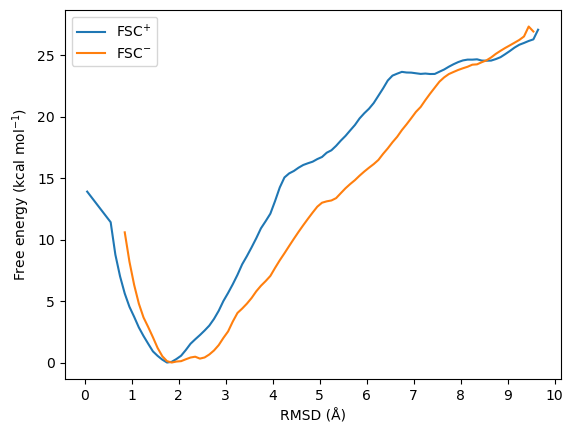

In [20]:
sns.lineplot(x='Coor', y='Free', data=colv_FSC_iwrap0_t1_free_df, label='FSC$^{+}$')
sns.lineplot(x='Coor', y='Free', data=colv_iwrap0_t1_free_df, label='FSC$^{-}$')

plt.xlabel('RMSD (Å)')
plt.ylabel('Free energy (kcal mol$^{-1}$)')
plt.xticks(np.arange(0, 11, step=1))
plt.show()

### (NG) Replicate 4
1. `iwrap=0` `trial2`
2. GTX TITAN X

#### FSC$^{+}$
`B2/receptor_FSC/prod_colv_iwrap0_dat/trial2`

In [21]:
colv0_FSC_iwrap0_t2_path = 'B2/receptor_FSC/prod_colv_iwrap0_dat/trial2/colv0.dat'
colv1_FSC_iwrap0_t2_path = 'B2/receptor_FSC/prod_colv_iwrap0_dat/trial2/colv1.dat'
colv2_FSC_iwrap0_t2_path = 'B2/receptor_FSC/prod_colv_iwrap0_dat/trial2/colv2.dat'
colv3_FSC_iwrap0_t2_path = 'B2/receptor_FSC/prod_colv_iwrap0_dat/trial2/colv3.dat'
colv4_FSC_iwrap0_t2_path = 'B2/receptor_FSC/prod_colv_iwrap0_dat/trial2/colv4.dat'
colv5_FSC_iwrap0_t2_path = 'B2/receptor_FSC/prod_colv_iwrap0_dat/trial2/colv5.dat'
colv6_FSC_iwrap0_t2_path = 'B2/receptor_FSC/prod_colv_iwrap0_dat/trial2/colv6.dat'
colv7_FSC_iwrap0_t2_path = 'B2/receptor_FSC/prod_colv_iwrap0_dat/trial2/colv7.dat'
colv8_FSC_iwrap0_t2_path = 'B2/receptor_FSC/prod_colv_iwrap0_dat/trial2/colv8.dat'
colv9_FSC_iwrap0_t2_path = 'B2/receptor_FSC/prod_colv_iwrap0_dat/trial2/colv9.dat'

colv0_FSC_iwrap0_t2_df = pd.read_csv(colv0_FSC_iwrap0_t2_path, comment='#', delim_whitespace=True, header=None, names=column_names)
display(colv0_FSC_iwrap0_t2_df)

colv1_FSC_iwrap0_t2_df = pd.read_csv(colv1_FSC_iwrap0_t2_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv2_FSC_iwrap0_t2_df = pd.read_csv(colv2_FSC_iwrap0_t2_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv3_FSC_iwrap0_t2_df = pd.read_csv(colv3_FSC_iwrap0_t2_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv4_FSC_iwrap0_t2_df = pd.read_csv(colv4_FSC_iwrap0_t2_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv5_FSC_iwrap0_t2_df = pd.read_csv(colv5_FSC_iwrap0_t2_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv6_FSC_iwrap0_t2_df = pd.read_csv(colv6_FSC_iwrap0_t2_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv7_FSC_iwrap0_t2_df = pd.read_csv(colv7_FSC_iwrap0_t2_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv8_FSC_iwrap0_t2_df = pd.read_csv(colv8_FSC_iwrap0_t2_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv9_FSC_iwrap0_t2_df = pd.read_csv(colv9_FSC_iwrap0_t2_path, comment='#', delim_whitespace=True, header=None, names=column_names)

,MD time (ps),Collective variable (1:1)
0,4000.0,0.000506
1,4001.0,0.574900
2,4002.0,0.595212
3,4003.0,0.546605
4,4004.0,0.668898
...,...,...
9995,13995.0,1.188110
9996,13996.0,1.246570
9997,13997.0,1.300354
9998,13998.0,1.301836


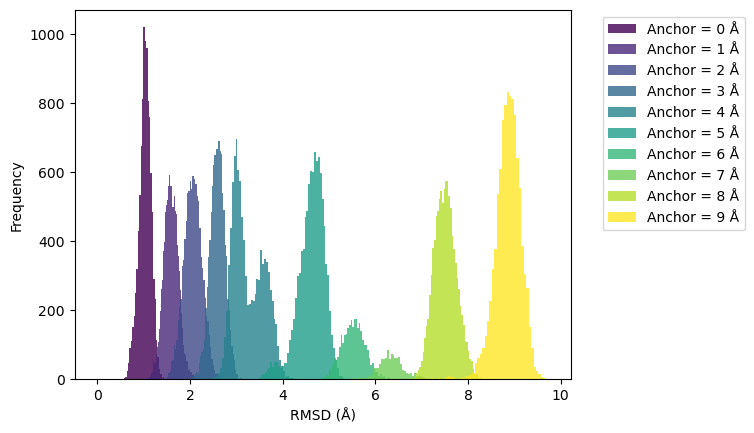

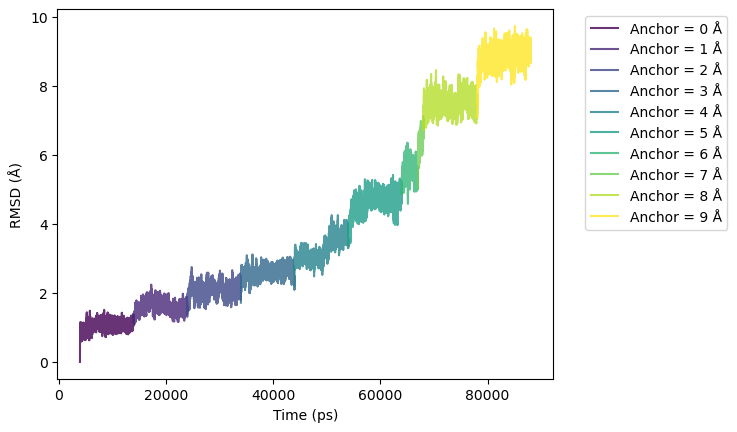

In [22]:
df_list = [colv0_FSC_iwrap0_t2_df, colv1_FSC_iwrap0_t2_df, colv2_FSC_iwrap0_t2_df, colv3_FSC_iwrap0_t2_df, colv4_FSC_iwrap0_t2_df, colv5_FSC_iwrap0_t2_df, colv6_FSC_iwrap0_t2_df, colv7_FSC_iwrap0_t2_df, colv8_FSC_iwrap0_t2_df, colv9_FSC_iwrap0_t2_df]

colors = cmap(np.linspace(0, 1, len(df_list)))

for df, label, color in zip(df_list, labels, colors):
    sns.histplot(df["Collective variable (1:1)"], bins=50, label=label, alpha=0.8, color=color, edgecolor='none')

plt.xlabel("RMSD (Å)")
plt.ylabel("Frequency")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

for df, label, color in zip(df_list, labels, colors):
    sns.lineplot(data=df, x="MD time (ps)", y="Collective variable (1:1)", label=label, alpha=0.8, color=color)

plt.xlabel("Time (ps)")
plt.ylabel("RMSD (Å)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

#### (NG) FSC$^{-}$
`B2/receptor/prod_colv_iwrap0_dat/trial2`

WRONG `colv*.in` coordinates (used FSC$^{+}$ values $\because$ copy+paste)

In [23]:
colv0_iwrap0_t2_path = 'B2/receptor/prod_colv_iwrap0_dat/trial2/colv0.dat'
colv1_iwrap0_t2_path = 'B2/receptor/prod_colv_iwrap0_dat/trial2/colv1.dat'
colv2_iwrap0_t2_path = 'B2/receptor/prod_colv_iwrap0_dat/trial2/colv2.dat'
colv3_iwrap0_t2_path = 'B2/receptor/prod_colv_iwrap0_dat/trial2/colv3.dat'
colv4_iwrap0_t2_path = 'B2/receptor/prod_colv_iwrap0_dat/trial2/colv4.dat'
colv5_iwrap0_t2_path = 'B2/receptor/prod_colv_iwrap0_dat/trial2/colv5.dat'
colv6_iwrap0_t2_path = 'B2/receptor/prod_colv_iwrap0_dat/trial2/colv6.dat'
colv7_iwrap0_t2_path = 'B2/receptor/prod_colv_iwrap0_dat/trial2/colv7.dat'
colv8_iwrap0_t2_path = 'B2/receptor/prod_colv_iwrap0_dat/trial2/colv8.dat'
colv9_iwrap0_t2_path = 'B2/receptor/prod_colv_iwrap0_dat/trial2/colv9.dat'

colv0_iwrap0_t2_df = pd.read_csv(colv0_iwrap0_t2_path, comment='#', delim_whitespace=True, header=None, names=column_names)
display(colv0_iwrap0_t2_df)

colv1_iwrap0_t2_df = pd.read_csv(colv1_iwrap0_t2_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv2_iwrap0_t2_df = pd.read_csv(colv2_iwrap0_t2_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv3_iwrap0_t2_df = pd.read_csv(colv3_iwrap0_t2_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv4_iwrap0_t2_df = pd.read_csv(colv4_iwrap0_t2_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv5_iwrap0_t2_df = pd.read_csv(colv5_iwrap0_t2_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv6_iwrap0_t2_df = pd.read_csv(colv6_iwrap0_t2_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv7_iwrap0_t2_df = pd.read_csv(colv7_iwrap0_t2_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv8_iwrap0_t2_df = pd.read_csv(colv8_iwrap0_t2_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv9_iwrap0_t2_df = pd.read_csv(colv9_iwrap0_t2_path, comment='#', delim_whitespace=True, header=None, names=column_names)

,MD time (ps),Collective variable (1:1)
0,4000.0,1.740392
1,4001.0,1.677311
2,4002.0,1.663176
3,4003.0,1.567370
4,4004.0,1.494617
...,...,...
9995,13995.0,1.047918
9996,13996.0,1.122689
9997,13997.0,0.992216
9998,13998.0,0.948819


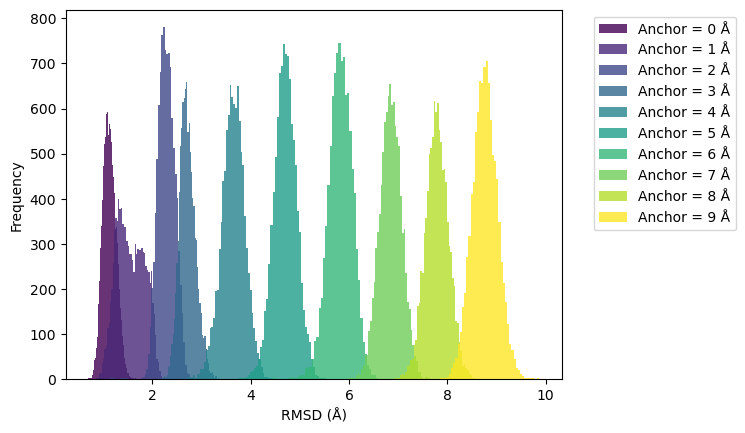

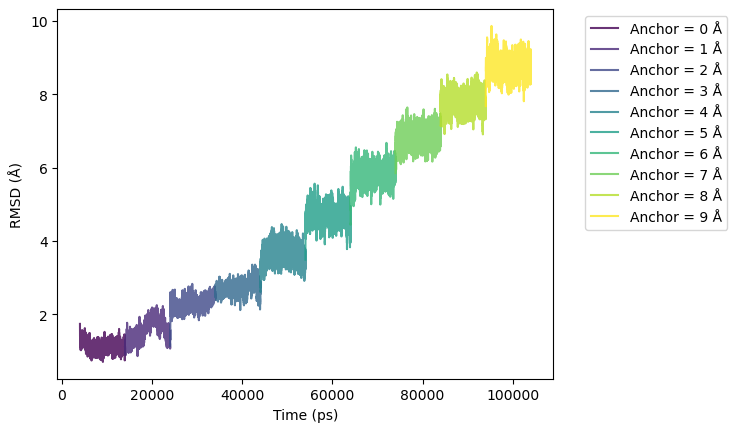

In [24]:
df_list = [colv0_iwrap0_t2_df, colv1_iwrap0_t2_df, colv2_iwrap0_t2_df, colv3_iwrap0_t2_df, colv4_iwrap0_t2_df, colv5_iwrap0_t2_df, colv6_iwrap0_t2_df, colv7_iwrap0_t2_df, colv8_iwrap0_t2_df, colv9_iwrap0_t2_df]

colors = cmap(np.linspace(0, 1, len(df_list)))

for df, label, color in zip(df_list, labels, colors):
    sns.histplot(df["Collective variable (1:1)"], bins=50, label=label, alpha=0.8, color=color, edgecolor='none')

plt.xlabel("RMSD (Å)")
plt.ylabel("Frequency")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

for df, label, color in zip(df_list, labels, colors):
    sns.lineplot(data=df, x="MD time (ps)", y="Collective variable (1:1)", label=label, alpha=0.8, color=color)

plt.xlabel("Time (ps)")
plt.ylabel("RMSD (Å)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

#### (NG) Free energy comparison
seems like wrong starting coordinates lead to "shifted" free energy curve?

In [25]:
colv_FSC_iwrap0_t2_free_path = 'B2/receptor_FSC/prod_colv_iwrap0_dat/trial2/result_bootstrap.dat'
colv_iwrap0_t2_free_path = 'B2/receptor/prod_colv_iwrap0_dat/trial2/result_bootstrap.dat'

colv_FSC_iwrap0_t2_free_df = (pd.read_csv(colv_FSC_iwrap0_t2_free_path, delim_whitespace=True, skiprows=1, names=['Coor', 'Free', '+/-Free', 'Prob', '+/-Prob']).iloc[:100].replace('inf', np.nan).apply(pd.to_numeric))
display(colv_FSC_iwrap0_t2_free_df)

colv_iwrap0_t2_free_df = (pd.read_csv(colv_iwrap0_t2_free_path, delim_whitespace=True, skiprows=1, names=['Coor', 'Free', '+/-Free', 'Prob', '+/-Prob']).iloc[:100].replace('inf', np.nan).apply(pd.to_numeric))
display(colv_iwrap0_t2_free_df)

,Coor,Free,+/-Free,Prob,+/-Prob
0,0.05,15.786176,NaN,0.0,0.0
1,0.15,NaN,0.297845,0.0,0.0
2,0.25,NaN,NaN,0.0,0.0
3,0.35,NaN,NaN,0.0,0.0
4,0.45,NaN,NaN,0.0,0.0
...,...,...,...,...,...
95,9.55,29.303693,0.171422,0.0,0.0
96,9.65,29.805099,NaN,0.0,0.0
97,9.75,30.094431,NaN,0.0,0.0
98,9.85,NaN,NaN,0.0,0.0


,Coor,Free,+/-Free,Prob,+/-Prob
0,0.05,NaN,NaN,0.0,0.0
1,0.15,NaN,NaN,0.0,0.0
2,0.25,NaN,NaN,0.0,0.0
3,0.35,NaN,NaN,0.0,0.0
4,0.45,NaN,NaN,0.0,0.0
...,...,...,...,...,...
95,9.55,14.713096,0.192571,0.0,0.0
96,9.65,14.581588,0.288066,0.0,0.0
97,9.75,14.225588,NaN,0.0,0.0
98,9.85,13.602428,NaN,0.0,0.0


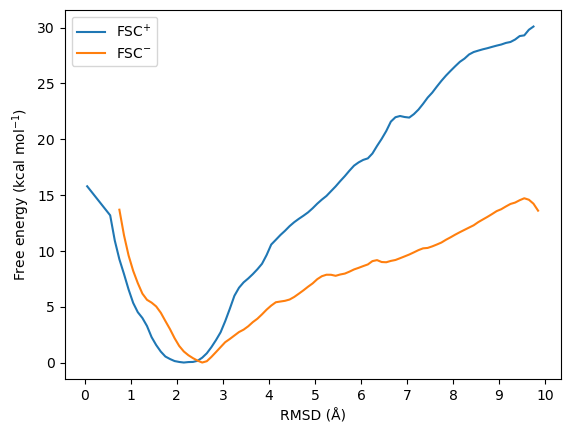

In [26]:
sns.lineplot(x='Coor', y='Free', data=colv_FSC_iwrap0_t2_free_df, label='FSC$^{+}$')
sns.lineplot(x='Coor', y='Free', data=colv_iwrap0_t2_free_df, label='FSC$^{-}$')

plt.xlabel('RMSD (Å)')
plt.ylabel('Free energy (kcal mol$^{-1}$)')
plt.xticks(np.arange(0, 11, step=1))
plt.show()

but even with wrong starting coordinates,\
the overall trend is the same?!

## Hamiltonian replica exchange with umbrella sampling
Continue from Replicate 1 $\because$ use AMBER20 in cluster

### FSC$^{+}$

### FSC$^{-}$

## 50 ns NVT production MD
To compare free energy minima from RMSD restrained umbrella sampling to equilibrium RMSD after unrestrained production MD

NVT to keep production conditions constant

### FSC$^{+}$

### FSC$^{-}$